# Summary analysis for shoaling QTL mapping


- Adapted from ShoalingSelectionAnalysis_2025_slim_clean.ipynb
- For this to work, you need to adapt the folder where raw data and metaData live.
- Also, you need to clone the jlsocialbehavior repository and create the environment jlsocial from the yml file.

## Define input and output folders. Give metadata location

In [50]:
# Find the username dynamically, this will allow the script to work in different computers without hardcoding the username
import os

import getpass
username = getpass.getuser()
print(username)


crodri19


In [51]:

#define input and ouitput folders. Give location of metadata and the file name

# base = 'Y://Johannes//b//2019//' This is the original base folder where the meta data was stored
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/'  # Updated base folder. Metadata should live here.
codeDir = 'C:/Users/crodri19/larschpostdoc_analyses/selection_shoaling/jlsocialbehavior/' #adapt this to your code folder
metaFile='MetaData_QTL.xlsx'
ProcessingDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/'
outputDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/'

print('searching for meta info here: ' + metaFolder)

os.chdir(codeDir)

searching for meta info here: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/


## Import necessary python libraries

In [52]:

# Import necessary python libraries


import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms

%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
import fnmatch

import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
import glob
#import h5py
from datetime import datetime
import PythonMeta as PMA
from matplotlib.ticker import AutoLocator

import functions.matrixUtilities_joh as mu
import functions.notebookHelper as nh
import functions.metaTree as mt

import models.experiment as xp
import models.experiment_set as es
import functions.paperFigureProps as pfp

from scipy import stats

pfp.paper()

using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


## Load experiment and animal metadata


In [53]:
# Check if the meta folder exists and list files
files = os.listdir('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL')
print(files)


# Save sheet with experiment info in table 'info'
info=pd.read_excel(metaFolder+metaFile, sheet_name='AllExp')
info

['20260511_q1_Sel1A_s1', '20260511_q2_Sel1A_s2', '20260512_q3_Sel3C_s1', '20260512_q4_Sel3C_s2', '20260518_q5_Sel3D_s1', '20260518_q6_Sel3D_s2', '20260519_q7_Sel1B_s1', '20260519_q8_Sel1B_s2', '20260626_q9_Sel1A_s2', '20260731_q10_Sel3A_s1', '20260731_q11_Sel3A_s2', '20260806_q12_Sel3C_s1', '20260806_q13_Sel3C_s2', 'MetaData_QTL - backup.xlsx', 'MetaData_QTL.xlsx']


,expNr,date,stimulusProtocol,set,path,folder,setup,anNr,first_anNR,first_anNR.1,tanks,notes
0,1,11-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260511_q1_Sel1A_s1,1,1:35,1,35,L746-L749,This experiment had a bug and was terminated a...
1,2,11-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260511_q2_Sel1A_s2,2,36:70,36,70,L746-L749,NaN
2,3,12-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260512_q3_Sel3C_s1,1,71:105,71,105,L750-L753,NaN
3,4,12-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260512_q4_Sel3C_s2,2,106:140,106,140,L750-L753,NaN
4,5,18-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260518_q5_Sel3D_s1,1,141:175,141,175,L767-L770,NaN
5,6,18-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260518_q6_Sel3D_s2,2,176:210,176,210,L767-L771,NaN
6,7,19-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260519_q7_Sel1B_s1,1,211:245,211,245,L771-L774,NaN
7,8,19-05-2026,trajectories_35wellPlate_SelectionTestProtocol,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260519_q8_Sel1B_s2,2,246:280,246,280,L771-L774,NaN
8,9,26-06-2026,trajectories_35wp_MixShoalLoomSepShoalLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260626_q9_Sel1A_s2,2,281:315,281,315,L797-L798,Tanks very dirty with excess food on the day o...
9,10,31-07-2026,QTLmap_35wp_MixShoalSimpleLoom30TuningLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260731_q10_Sel3A_s1,1,316:350,316,350,L838-L840,NaN


In [54]:
# infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd','expDate'])
# infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%Y%m%d')
# infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%Y%m%d')
# infoAn.tail()

#Save metadata sheet with individual animal info into the 'infoAn' table

infoAn = pd.read_excel(metaFolder + metaFile, sheet_name='AllAn')
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%d-%m-%Y', dayfirst=True)
infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%d-%m-%Y', dayfirst=True)
# Exclude the new NA genotype everywhere by removing it before any downstream merge or plot.
infoAn = infoAn.loc[infoAn['genotype'].notna() & infoAn['genotype'].astype(str).str.lower().ne('na')].copy()
infoAn.tail(150)

,anNr,line,genotype,cohort,bd,expNr,expDate,coordinates,anexpID,anLabID,QTLID,Comments
270,271,Sel1B,F2,na,2026-05-01,8,2026-05-19,D5,26,L773_f26,Q8_D5,NaN
271,272,Sel1B,F2,na,2026-05-01,8,2026-05-19,D6,27,L773_f27,Q8_D6,NaN
272,273,Sel1B,F2,na,2026-05-01,8,2026-05-19,D7,28,L773_f28,Q8_D7,NaN
273,274,Sel1B,esc,na,2026-05-01,8,2026-05-19,E1,29,L773_f29,Q8_E1,NaN
274,275,Sel1B,F2,na,2026-05-01,8,2026-05-19,E2,30,L773_f30,Q8_E2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
446,447,Sel3C,F2,na,2026-07-21,13,2026-08-06,D6,27,L845_f27,Q13_D6,NaN
447,448,Sel3C,F2,na,2026-07-21,13,2026-08-06,D7,28,L845_f28,Q13_D7,NaN
448,449,Sel3C,F2,na,2026-07-21,13,2026-08-06,E1,29,L845_f29,Q13_E1,NaN
449,450,Sel3C,F2,na,2026-07-21,13,2026-08-06,E2,30,L845_f30,Q13_E2,NaN


In [55]:
infoAn.genotype.unique()

array(['F2', 'esc'], dtype=object)

## Prepare processing settings


In [56]:
# collect video (?) meta information and save to new csv file for batch processing

aviPath=[]
posPath=[]
PLPath=[]
expTime = []
birthDayAll=[]
anIDsAll=[]
camHeightAll=[]

camHeight=[105,180] # these are outdated values, but we keep them for compatibility with old data

for index,row in info.iterrows():

    startDir=row.path+'\\'+row.folder+'\\'
    print('processing: ' + startDir)
    if not os.path.exists(startDir):
        print('WARNING: path does not exist: ' + startDir)
        continue

    
    posPath.append(glob.glob(startDir+'PositionTxt*')[0]) #this is the trajectory file
    PLPath.append(glob.glob(startDir+'PL*')[0]) # this is the pair list file
    
    head, tail = os.path.split(posPath[-1])
    currTime='dummy' #datetime.strptime(tail[-23:-4], '%Y-%m-%dT%H_%M_%S')
    expTime.append(currTime)
    
    camHeightAll.append(camHeight[('_dn_' in head)*1]) ######### this needs to be adapted for new data, since the camHeight is not stored in the meta data anymore.
    
    anNrs=row.anNr #Note that anNrs are 1 based!
    if ':' in anNrs:
        a,b=anNrs.split(sep=':')
        anNrs=np.arange(int(a),int(b)+1)
    else:
        anNrs=np.array(anNrs.split()).astype(int)
        
    anIDs=anNrs #-1 no more 0-based since using pandas merge to find animal numbers
    anIDsAll.extend(anIDs)

    bd=infoAn[infoAn.anNr.isin(anIDs)].bd.values.astype(str) # get birth dates of animals in this experiment
    #bd=infoAn.bd.values[anIDs-1] #a bit dirty to use anIDs directly here. Should merge
    birthDayAll.append(' '.join(list(bd)))

info['camHeight']=camHeightAll
info['txtPath']=posPath
info['pairList']=PLPath
info['aviPath']='default'
info['birthDayAll']=birthDayAll
info['epiDur'] = 5      # duration of individual episodes (default: 5 minutes)
info['episodes'] = 24   # number of episodes to process: -1 to load all episodes (default: -1)
info['inDish'] = 10#np.arange(len(posPath))*120     # time in dish before experiments started (default: 10)
info['arenaDiameter_mm'] = 70 # arena diameter (default: 100 mm)
info['minShift'] = 60 # minimum number of seconds to shift for control IAD
info['episodePLcode'] = 0 # flag if first two characters of episode name encode animal pair matrix (default: 0)
info['recomputeAnimalSize'] = 1 # flag to compute animals size from avi file (takes time, default: 1)
info['SaveNeighborhoodMaps'] = 0 # flag to save neighborhood maps for subsequent analysis (takes time, default: 1)
info['computeLeadership'] = 0 # flag to compute leadership index (takes time, default: 1)
info['ComputeBouts'] = 1 # flag to compute swim bout frequency (takes time, default: 1)
#info['set'] = np.arange(len(posPath))   # experiment set: can label groups of experiments (default: 0)
info['ProcessingDir']=ProcessingDir
info['outputDir']=outputDir
info['expTime']=expTime
info['readLim'] = 24*5*60*30+11

processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q1_Sel1A_s1\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q2_Sel1A_s2\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260512_q3_Sel3C_s1\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260512_q4_Sel3C_s2\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260518_q5_Sel3D_s1\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260518_q6_Sel3D_s2\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260519_q7_Sel1B_s1\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260519_q8_Sel1B_s2\
processing: \\nasdcsr.un

In [57]:
csvFile=os.path.join(ProcessingDir,'processingSettings.csv')
info.to_csv(csvFile,encoding='utf-8')
info.tail()

,expNr,date,stimulusProtocol,set,path,folder,setup,anNr,first_anNR,first_anNR.1,...,minShift,episodePLcode,recomputeAnimalSize,SaveNeighborhoodMaps,computeLeadership,ComputeBouts,ProcessingDir,outputDir,expTime,readLim
8,9,26-06-2026,trajectories_35wp_MixShoalLoomSepShoalLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260626_q9_Sel1A_s2,2,281:315,281,315,...,60,0,1,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
9,10,31-07-2026,QTLmap_35wp_MixShoalSimpleLoom30TuningLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260731_q10_Sel3A_s1,1,316:350,316,350,...,60,0,1,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
10,11,31-07-2026,QTLmap_35wp_MixShoalSimpleLoom30TuningLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260731_q11_Sel3A_s2,2,351:385,351,385,...,60,0,1,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
11,12,06-08-2026,QTLmap_35wp_MixShoalSimpleLoom30TuningLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260806_q12_Sel3C_s1,1,386:420,386,420,...,60,0,1,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
12,13,06-08-2026,QTLmap_35wp_MixShoalSimpleLoom30TuningLoom,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20260806_q13_Sel3C_s2,2,421:455,421,455,...,60,0,1,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011


## Read experiment data and processed shoaling summaries


In [58]:
rereadData=1
if rereadData:
    def readExperiment(keepData=True):
        tmp=es.experiment_set(csvFile=csvFile,MissingOnly=True)
        if keepData:
            return tmp
        else:
            return 1

    expSet=readExperiment(keepData=False)

False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/PositionTxt_allROI2026-05-11T13_45_12*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/PositionTxt_allROI2026-05-11T13_45_37*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/PositionTxt_allROI2026-05-12T11_47_49*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/PositionTxt_allROI2026-05-12T11_45_00*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/PositionTxt_allROI2026-05-18T10_59_16*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jla

In [59]:
csvPath = []
for f in [mu.splitall(x)[-1][:-4] for x in info.txtPath]:
    csvPath.append(glob.glob(ProcessingDir+f+'*siSummary*.csv')[0])

df=pd.DataFrame()
i=0
for fn in csvPath:
    print(fn)
    tmp=pd.read_csv(fn,index_col=0,sep=',')
    tmp.animalSet=i
    tmp.animalIndex=tmp.animalIndex+((i)*35)
    tmp.animalIndex=np.array(anIDsAll)[tmp.animalIndex]
    df=pd.concat([df,tmp])
    i+=1
df['episode']=[x.strip().replace('_','') for x in df['episode']]
df=pd.merge(df,infoAn[['anNr','line','genotype']],left_on='animalIndex',right_on='anNr',how='left')
df=pd.merge(df,info[['date']],left_on='animalSet',right_on=info.index,how='left')
df['setup'] = info['setup'].values[df['animalSet'].values]
# Drop rows that belong to the NA genotype before building downstream experiment labels.
df = df.loc[
    df['genotype'].notna()
    & df['genotype'].astype(str).str.lower().ne('na')
    & df['line'].notna()
    & df['date'].notna()
].copy()
print('df shape',df.shape)
df['lineSet']=[x+'_'+y for x,y in zip(df.line, df.date)]


//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing\PositionTxt_allROI2026-05-11T13_45_12_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing\PositionTxt_allROI2026-05-11T13_45_37_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing\PositionTxt_allROI2026-05-12T11_47_49_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing\PositionTxt_allROI2026-05-12T11_45_00_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing\PositionTxt_allROI2026-05-18T10_59_16_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoal

In [60]:
#df.tail(40)
df
#df.animalSet.unique()

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,boutDur,leadershipIndex,sync_amp,sync_t,anNr,line,genotype,date,setup,lineSet
0,0,1,0,35,-0.070813,01k01f,0,10.0,0,10.0,...,0.833333,0,0,0,1.0,Sel1A,F2,11-05-2026,1,Sel1A_11-05-2026
1,0,2,1,35,-0.006723,01k01f,0,10.0,0,10.0,...,0.566667,0,0,0,2.0,Sel1A,F2,11-05-2026,1,Sel1A_11-05-2026
2,0,3,2,35,0.157343,01k01f,0,10.0,0,10.0,...,0.533333,0,0,0,3.0,Sel1A,F2,11-05-2026,1,Sel1A_11-05-2026
3,0,4,3,35,-0.005104,01k01f,0,10.0,0,10.0,...,0.600000,0,0,0,4.0,Sel1A,F2,11-05-2026,1,Sel1A_11-05-2026
4,0,5,4,35,-0.025189,01k01f,0,10.0,0,10.0,...,0.666667,0,0,0,5.0,Sel1A,F2,11-05-2026,1,Sel1A_11-05-2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10736,12,447,26,35,0.092207,02k20f,207000,125.0,23,125.0,...,0.866667,0,0,0,447.0,Sel3C,F2,06-08-2026,2,Sel3C_06-08-2026
10737,12,448,27,35,0.147628,02k20f,207000,125.0,23,125.0,...,0.633333,0,0,0,448.0,Sel3C,F2,06-08-2026,2,Sel3C_06-08-2026
10738,12,449,28,35,0.109433,02k20f,207000,125.0,23,125.0,...,0.933333,0,0,0,449.0,Sel3C,F2,06-08-2026,2,Sel3C_06-08-2026
10739,12,450,29,35,0.111637,02k20f,207000,125.0,23,125.0,...,0.666667,0,0,0,450.0,Sel3C,F2,06-08-2026,2,Sel3C_06-08-2026


## Build episode-level animal summaries


In [61]:
sns.set_palette('viridis',3)
co=sns.color_palette("viridis", 3)
idx=(df['inDishTime']<240) & (df['inDishTime']>80) # PUT THIS SETTING ON THE TOP - ANALYSIS WINDOW BETWEEN 80 AND 240s
dfDR=df[idx]
dfEpiAn=dfDR.groupby(['episode','animalIndex','line','setup','genotype','date','lineSet'],sort=True).mean(numeric_only=True).reset_index()

In [62]:
#dfEpiAn.head()
dfEpiAn

,episode,animalIndex,line,setup,genotype,date,lineSet,animalSet,animalID,CurrentPartner,...,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr
0,01k01f,1,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,0.0,35.0,...,0.0,7.558374,6.337527,7.329442,18.317183,0.816667,0.0,0.0,0.0,1.0
1,01k01f,2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,1.0,35.0,...,0.0,6.812819,5.325227,7.654782,17.126884,0.666667,0.0,0.0,0.0,2.0
2,01k01f,3,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,2.0,35.0,...,0.0,12.608883,11.212608,6.947497,18.767604,0.566667,0.0,0.0,0.0,3.0
3,01k01f,4,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,3.0,35.0,...,0.0,11.331526,8.846323,4.022061,19.947904,0.733333,0.0,0.0,0.0,4.0
4,01k01f,5,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,4.0,35.0,...,0.0,6.056469,4.427094,5.845555,21.168090,0.816667,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,02k20f,447,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,26.0,35.0,...,0.0,5.332646,3.829601,2.941723,19.151905,0.893333,0.0,0.0,0.0,447.0
812,02k20f,448,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,27.0,35.0,...,0.0,5.317276,3.587127,2.938998,17.077780,0.786667,0.0,0.0,0.0,448.0
813,02k20f,449,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,28.0,35.0,...,0.0,4.559394,2.786256,NaN,14.715632,0.980000,0.0,0.0,0.0,449.0
814,02k20f,450,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,29.0,35.0,...,0.0,6.754526,5.200948,1.887935,21.176296,0.693333,0.0,0.0,0.0,450.0


## Summary statistic helpers


In [63]:

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x))

x=np.random.random(100)

def ci95(x):
    return np.nanmean(x)-sms.DescrStatsW(x[np.isfinite(x)]).tconfint_mean()[0]

print('std of uniform = 0.2886751345948129. STDdata:',np.std(x), 'semData:',sem(x),'samples:',x.shape) 
print('ci95:',ci95(x))

std of uniform = 0.2886751345948129. STDdata: 0.28220022756794083 semData: 0.028362190018053568 samples: (100,)
ci95: 0.05627673821573237


In [64]:
dfPlot=(df.groupby(['inDishTime','episode','genotype','lineSet']).si.agg(['mean','std',sem,ci95])
    .unstack()
    .stack(dropna=True)
    .reset_index())

dfPlot.head()

C:\Users\crodri19\AppData\Local\Temp\ipykernel_10076\3738759538.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


,inDishTime,episode,genotype,lineSet,mean,std,sem,ci95
0,10.0,01k01f,F2,Sel1A_11-05-2026,0.036981,0.079606,0.010935,0.021942
1,10.0,01k01f,F2,Sel1A_26-06-2026,0.028957,0.070342,0.011890,0.024163
2,10.0,01k01f,F2,Sel1B_19-05-2026,0.013620,0.064472,0.008615,0.017266
3,10.0,01k01f,F2,Sel3A_31-07-2026,0.023641,0.084034,0.010940,0.021899
4,10.0,01k01f,F2,Sel3C_06-08-2026,0.010281,0.081231,0.011977,0.024123


## Shoaling index analyses

### Shoaling index throughout the experiment - linear vs bout

'//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/'

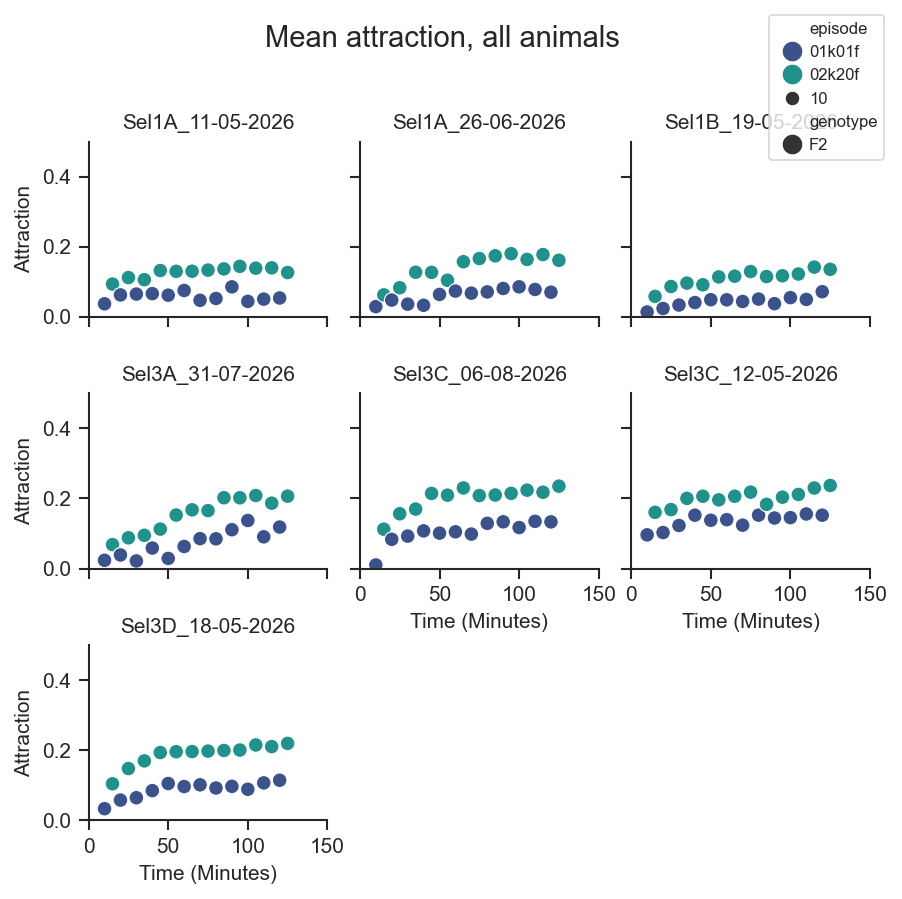

In [65]:
dfPlot_filtered = dfPlot[dfPlot['genotype'] == 'F2']
#dfPlot_filtered = dfPlot[~dfPlot['genotype'].str.contains(r'^(esc_(lo|hi)|na)$', regex=True)]


markers = {'F2': 'o'}  # "o" is a fake genotype, i get an error if I only use one marker


g = sns.FacetGrid(
    dfPlot_filtered,
    col='lineSet',         # Facet by genotype (change as needed)
    col_wrap=3,             # Adjust for compactness
    sharex=True,
    sharey=True,
    height=2,
    aspect=1
)
g.map_dataframe(
    sns.scatterplot,
    x='inDishTime',
    y='mean',
    hue='episode',
    style='genotype',
    size=10,
    markers=markers,
    legend='full',

)
g.set(xlim=(0, 2.5*60), ylim=(0, .5))
g.set_axis_labels('Time (Minutes)', 'Attraction')
g.set_titles('{col_name}')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Mean attraction, all animals', fontsize=14)

# Remove the default legend and add a correct one
for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove() if hasattr(ax, "legend_") and ax.legend_ else None

# Add a single legend to the figure
handles, labels = g.axes[0].get_legend_handles_labels()
g.figure.legend(handles, labels, ncol=1, handletextpad=0, bbox_to_anchor=(1, 1), loc='upper right')

# Save the plot using the path variable
g.figure.savefig(os.path.join(outputDir, "attraction_linearvsbout.pdf"), bbox_inches="tight")

outputDir

### Average shoaling index across assay time

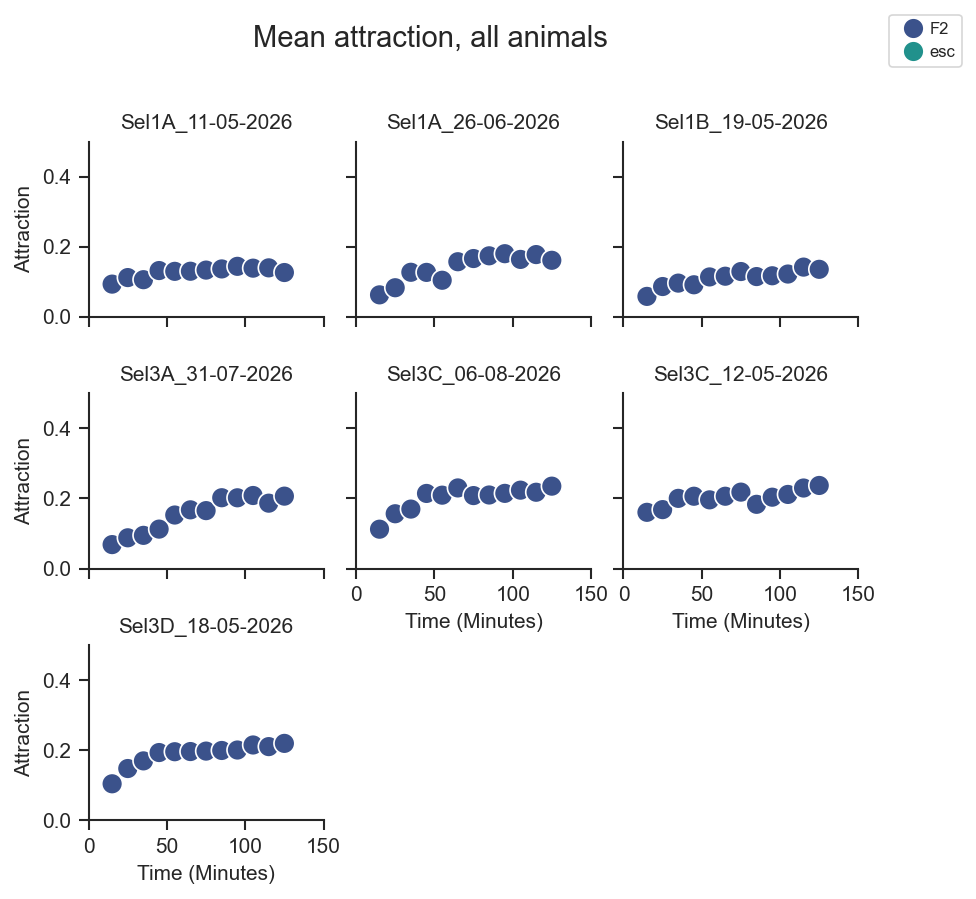

In [66]:
dfPlot_filtered2 = dfPlot[(dfPlot['genotype'] != 'esc') & (dfPlot['episode'] != '01k01f')]

g = sns.FacetGrid(
    dfPlot_filtered2,
    col='lineSet',         # Facet by genotype (change as needed)
    col_wrap=3,             # Adjust for compactness
    sharex=True,
    sharey=True,
    height=2,
    aspect=1
)
g.map_dataframe(
    sns.scatterplot,
    x='inDishTime',
    y='mean',
    hue='genotype',
    hue_order=["F2",'esc'],
    
)
g.set(xlim=(0, 2.5*60), ylim=(0, .5))
g.set_axis_labels('Time (Minutes)', 'Attraction')
g.set_titles('{col_name}')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Mean attraction, all animals', fontsize=14)

# Remove the default legend and add a correct one
for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove() if hasattr(ax, "legend_") and ax.legend_ else None

# Add a single legend to the figure
handles, labels = g.axes[0].get_legend_handles_labels()
g.figure.legend(handles, labels, ncol=1, handletextpad=0, bbox_to_anchor=(1, 1), loc='upper left')

# Save the plot using the path variable
g.figure.savefig(os.path.join(outputDir, "attraction_hivslo.pdf"), bbox_inches="tight")



### Shoaling index between setups

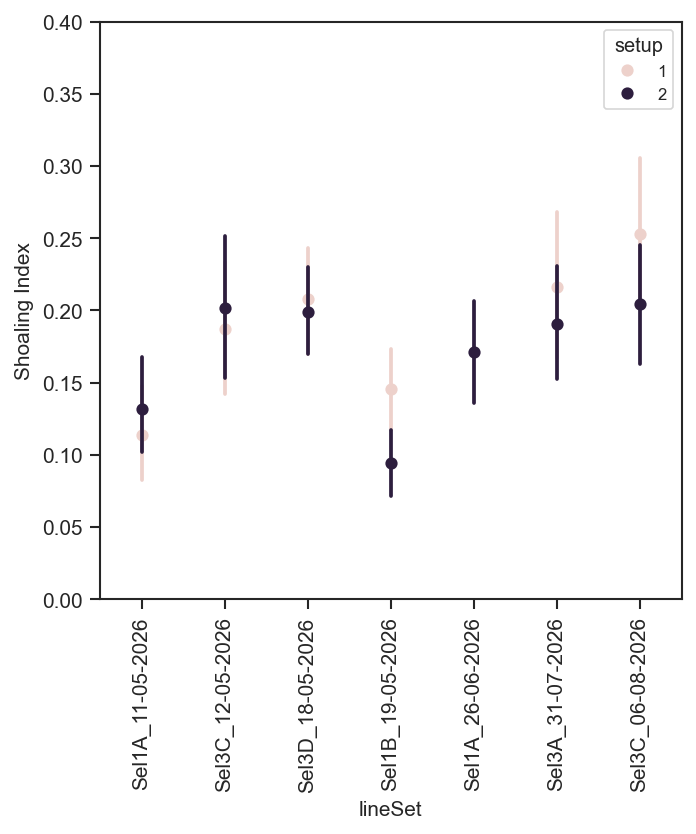

In [67]:
sns.pointplot(data=dfEpiAn[dfEpiAn.episode=='02k20f'],x='lineSet',y='si',hue='setup',linestyle='none')
plt.ylim([0,.4])
plt.xticks(rotation=90);
plt.ylabel('Shoaling Index');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "shoalindex_setups.pdf"), bbox_inches="tight")



### Shoaling index across experiments

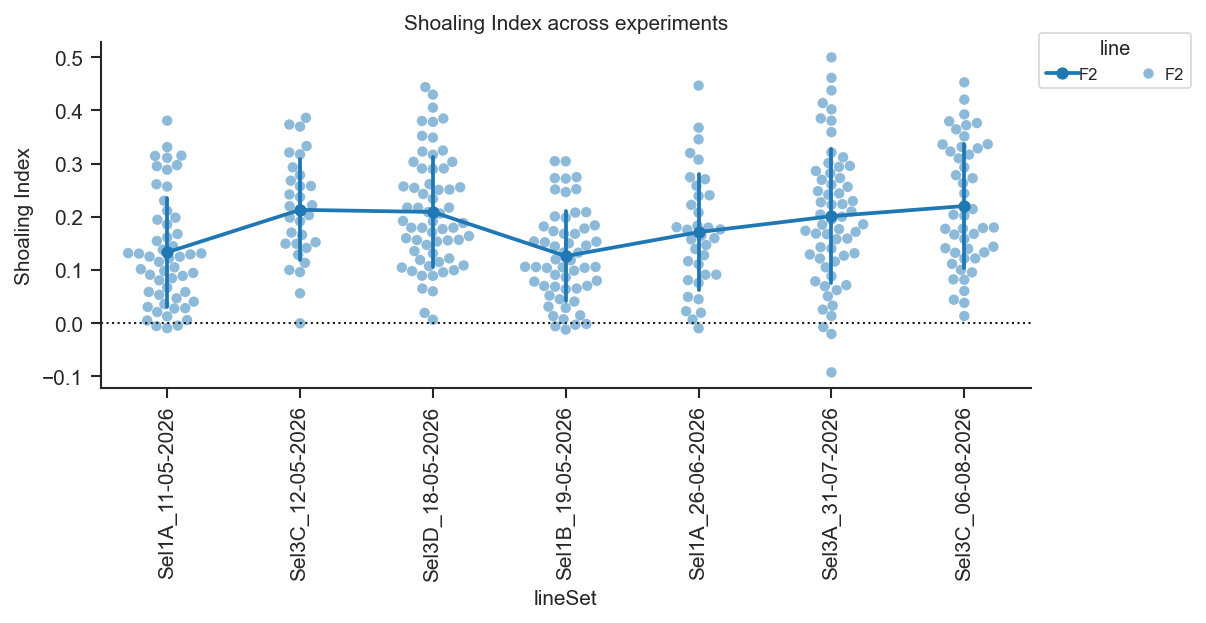

In [68]:
fig, axes = plt.subplots(figsize=(8,3))

#All data
#ix=(dfEpiAn.episode=='02k20f')

#exclude esc and 01k01f
ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='F2')) 


selDat=dfEpiAn[ix]

#Settings

show_lines = "All" 


if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

# Define custom colors for each genotype
genotype_hue_order = ['F2']
custom_palette = {'F2': "#1F77B4"}

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
             linestyle='-',
             errorbar='sd',
             hue_order=genotype_hue_order,
             palette=custom_palette)

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              zorder=-1,
              size=5,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             hue_order=genotype_hue_order,
             palette=custom_palette)

sns.despine()

axes.set_ylabel('Shoaling Index')
axes.axhline(0,ls=':',color='k')
axes.set_title('Shoaling Index across experiments');
plt.legend(title='line',ncol=2,handletextpad=0,bbox_to_anchor=(1, 1.05))
plt.xticks(rotation=90);




In [69]:
dfEpiAn.line.unique() #check existing lines

array(['Sel1A', 'Sel3C', 'Sel3D', 'Sel1B', 'Sel3A'], dtype=object)

### SI between normal and escapee fish

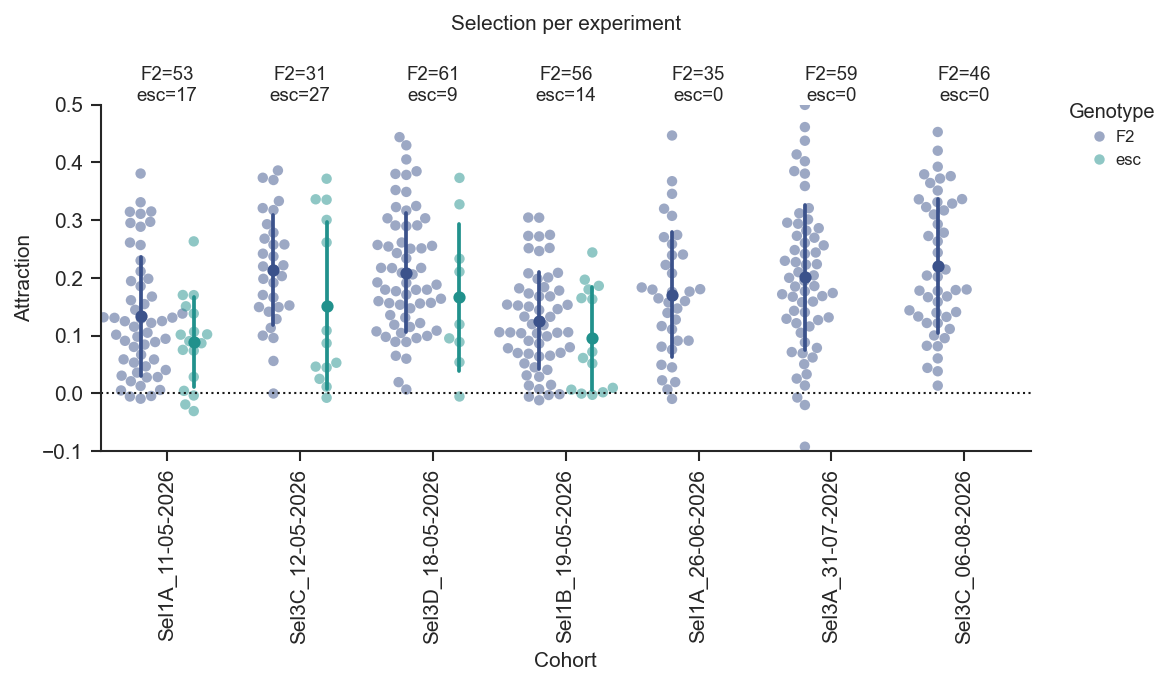

In [70]:
fig, axes = plt.subplots(figsize=(8, 3))
# Set this to True when you want to plot only the F2 samples and only show the F2 group size.
plot_only_F2 = False
plot_genotypes = ['F2'] if plot_only_F2 else ['F2', 'esc']
pointplot_dodge = 0 if plot_only_F2 else .4
ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype.isin(plot_genotypes))

selDat=dfEpiAn[ix]

#Settings

show_lines = "All" 
xlegend_orientation = 'vertical' #choose verticar or horizontal


if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

# Count the number of unique animals per experiment and genotype for the labels.
# These counts are used to annotate each cohort with the group size(s) above the plot.
group_columns = ['F2'] if plot_only_F2 else ['F2', 'esc']
group_sizes = (
    selDat.groupby(['lineSet', 'genotype'])['animalIndex']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=group_columns, fill_value=0)
    .fillna(0)
    .astype(int)
)

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              zorder=-1,
              dodge=.5,
              size=5,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             hue_order=plot_genotypes)

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              dodge=pointplot_dodge,
              # Draw only the summary points and error bars, without connecting lines across experiments.
              linestyle='none',
              errorbar='sd',
              hue_order=plot_genotypes)



sns.despine()
axes.set_ylim([-0.1,0.5])

axes.set_ylabel('Attraction')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

#Write the x-axis labels with the cohort names, and rotate them if needed to keep them readable.
# Read the current category labels after the seaborn plot has created the x-axis ticks.
xticklabels = [t.get_text() for t in axes.get_xticklabels()]
xticks = axes.get_xticks()
axes.set_xticks(xticks)
if xlegend_orientation == 'horizontal':
    # Keep labels flat when the layout is horizontal.
    axes.set_xticklabels(xticklabels, rotation=0)
else:
    # Rotate labels to keep long cohort names readable.
    axes.set_xticklabels(xticklabels, rotation=90)

# Annotate each cohort with the number of animals in each genotype group above the plot.
for xpos, label in zip(xticks, xticklabels):
    if label in group_sizes.index:
        f2_n = group_sizes.loc[label, 'F2'] if 'F2' in group_sizes.columns else 0
        if plot_only_F2:
            label_text = f'F2={f2_n}'
        else:
            esc_n = group_sizes.loc[label, 'esc'] if 'esc' in group_sizes.columns else 0
            label_text = f'F2={f2_n}\nesc={esc_n}'
        axes.text(
            xpos,
            1.00,
            label_text,
            transform=axes.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=9,
        )

# Keep the title above the group-size annotations, with extra padding so they do not crowd each other.
plt.title('Selection per experiment', pad=36);


handles, labels = axes.get_legend_handles_labels()
unique_handles = []
unique_labels = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

l = plt.legend(unique_handles, unique_labels, title='Genotype', ncol=1, handletextpad=0,
               bbox_to_anchor=(1.15, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')


# Save the plot using the path variable

if show_lines == "All":
    plt.savefig(os.path.join(outputDir, "shoalindex_hivslo.pdf"), bbox_inches="tight")


### Checking delta SI between bout and linear dots

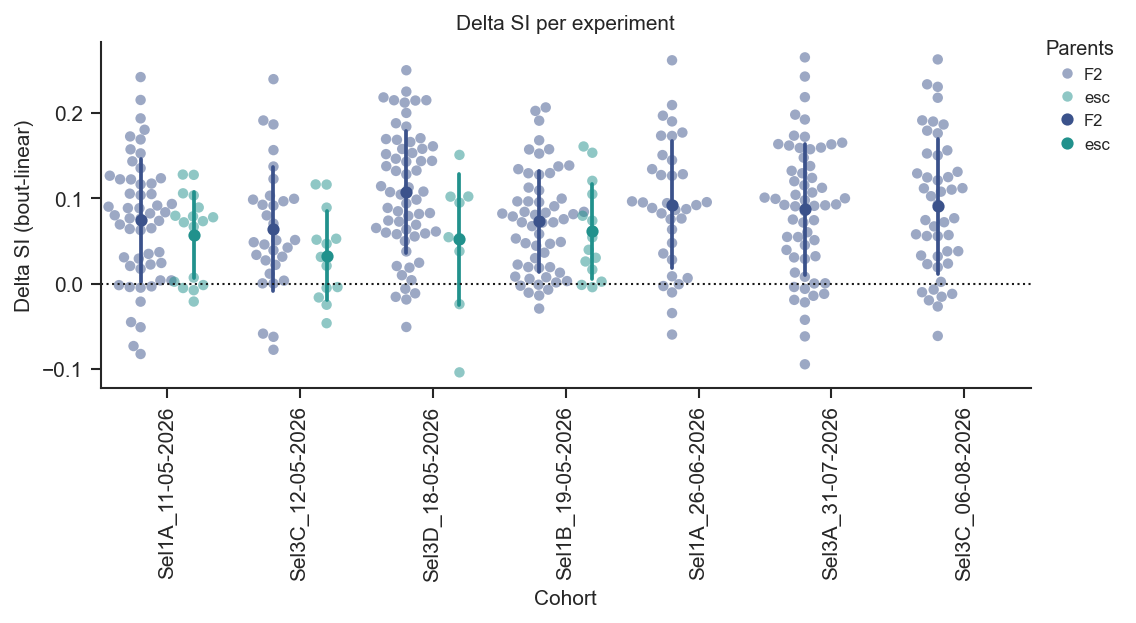

In [71]:
# ix=((dfEpiAn.genotype=='F2')) 

# mainDat=dfEpiAn[ix]


#Extract delta of shoaling index between linear and bout experiments
linear_data=dfEpiAn[dfEpiAn.episode=='01k01f']
bout_data=dfEpiAn[dfEpiAn.episode=='02k20f']

delta_data = bout_data.copy()
delta_data['si'] = bout_data['si'].values - linear_data['si'].values

delta_data['si'].values


fig, axes = plt.subplots(figsize=(8, 3))

selDat=delta_data
show_lines = "All" 
#show_lines = [ "Sel1_10", "Sel1_11"]  # set the lines you want to keep

if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              zorder=-1,
              dodge=.5,
              size=5,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             )

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              dodge=.4,
              linestyle='none',
              errorbar='sd',
              #hue_order=["hi", "lo",'wt','esc','mid'])
              )


sns.despine()

axes.set_ylabel('Delta SI (bout-linear)')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Delta SI per experiment');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "shoalindelta_hivslo.pdf"), bbox_inches="tight")


## Checking size, speed and SI across experiments

### Fish size across experiments

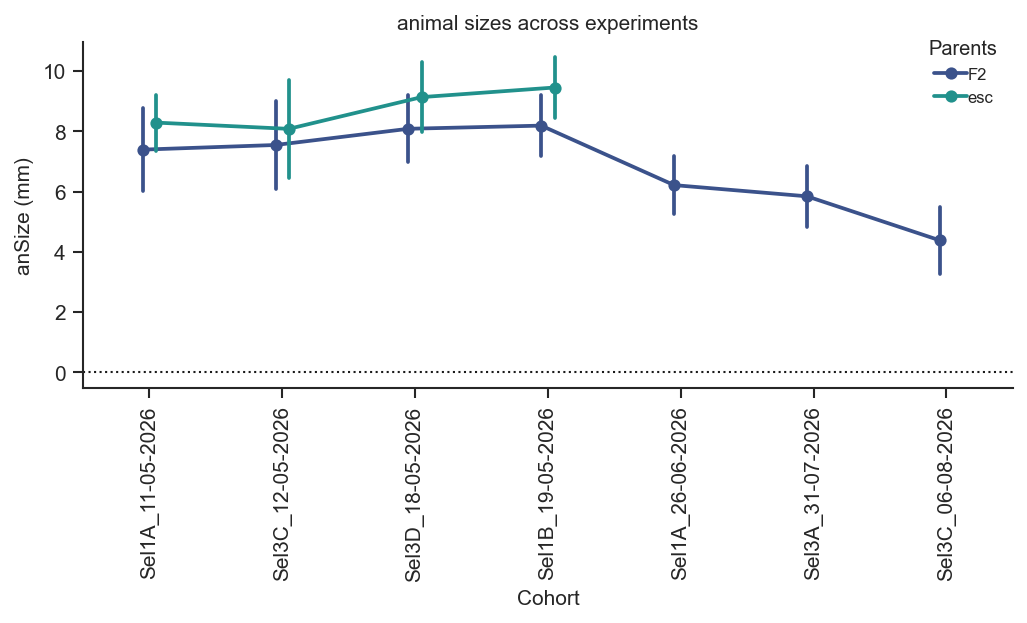

In [72]:
fig, axes = plt.subplots(figsize=(8, 3))
#ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo'))
ix=(dfEpiAn.episode=='02k20f')

selDat=dfEpiAn[ix]

show_lines = "All" 
#show_lines = [ "Sel1_10", "Sel1_11"]  # set the lines you want to keep

if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

# sns.swarmplot(data=selDat,
#               x='lineSet',
#               y='anSize',
#               hue='genotype',
#               zorder=-1,
#               dodge=.5,
#               size=4,
#               alpha=.5,
#               #order=allCat,
#              #hue_order=["hi", "lo",'wt','esc','mid'])
#              hue_order=["hi",'esc_hi', "lo",'esc_lo','wt','mid'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='anSize',
              hue='genotype',
              dodge=.1,
              linestyle='-',
              errorbar='sd',
              #hue_order=["hi", "lo",'wt','esc','mid'])
              hue_order=["F2",'esc'])


sns.despine()

axes.set_ylabel('anSize (mm)')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('animal sizes across experiments');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "anSize_hivslo.pdf"), bbox_inches="tight")



In [73]:

# #Subset data for only experiments happening from August 2025
# dfEpiAn.date = pd.to_datetime(dfEpiAn.date, format='%d-%m-%Y', dayfirst=True)
# dfEpiAn.date.dtype

# date_cutoff = pd.to_datetime('01-08-2025', format='%d-%m-%Y', dayfirst=True)

# dfEpiAn[dfEpiAn.date>=date_cutoff]
dfEpiAn

,episode,animalIndex,line,setup,genotype,date,lineSet,animalSet,animalID,CurrentPartner,...,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr
0,01k01f,1,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,0.0,35.0,...,0.0,7.558374,6.337527,7.329442,18.317183,0.816667,0.0,0.0,0.0,1.0
1,01k01f,2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,1.0,35.0,...,0.0,6.812819,5.325227,7.654782,17.126884,0.666667,0.0,0.0,0.0,2.0
2,01k01f,3,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,2.0,35.0,...,0.0,12.608883,11.212608,6.947497,18.767604,0.566667,0.0,0.0,0.0,3.0
3,01k01f,4,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,3.0,35.0,...,0.0,11.331526,8.846323,4.022061,19.947904,0.733333,0.0,0.0,0.0,4.0
4,01k01f,5,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,4.0,35.0,...,0.0,6.056469,4.427094,5.845555,21.168090,0.816667,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,02k20f,447,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,26.0,35.0,...,0.0,5.332646,3.829601,2.941723,19.151905,0.893333,0.0,0.0,0.0,447.0
812,02k20f,448,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,27.0,35.0,...,0.0,5.317276,3.587127,2.938998,17.077780,0.786667,0.0,0.0,0.0,448.0
813,02k20f,449,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,28.0,35.0,...,0.0,4.559394,2.786256,NaN,14.715632,0.980000,0.0,0.0,0.0,449.0
814,02k20f,450,Sel3C,2,F2,06-08-2026,Sel3C_06-08-2026,12.0,29.0,35.0,...,0.0,6.754526,5.200948,1.887935,21.176296,0.693333,0.0,0.0,0.0,450.0


### Animal size and SI correlation

,animalIndex,genotype,setup,animalSet,animalID,CurrentPartner,si,epStart,inDishTime,epiNr,...,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr
0,1,F2,1.0,0.0,0.0,35.0,0.161297,144000.0,90.0,16.0,...,0.0,8.003937,6.817780,7.329442,18.504032,0.766667,0.0,0.0,0.0,1.0
1,2,F2,1.0,0.0,1.0,35.0,0.211295,144000.0,90.0,16.0,...,0.0,7.056739,5.665709,7.654782,17.180630,0.616667,0.0,0.0,0.0,2.0
2,3,F2,1.0,0.0,2.0,35.0,0.121983,144000.0,90.0,16.0,...,0.0,10.530820,9.203485,6.947497,16.488376,0.583333,0.0,0.0,0.0,3.0
3,4,F2,1.0,0.0,3.0,35.0,0.005861,144000.0,90.0,16.0,...,0.0,11.215875,8.929157,4.022061,21.863410,0.733333,0.0,0.0,0.0,4.0
4,5,F2,1.0,0.0,4.0,35.0,0.088883,144000.0,90.0,16.0,...,0.0,6.264706,4.759834,5.845555,20.015502,0.816667,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,446,F2,2.0,12.0,25.0,35.0,0.121854,171000.0,105.0,19.0,...,0.0,7.323638,5.867368,2.603270,19.814248,0.746667,0.0,0.0,0.0,446.0
336,447,F2,2.0,12.0,26.0,35.0,0.178934,171000.0,105.0,19.0,...,0.0,5.332646,3.829601,2.941723,19.151905,0.893333,0.0,0.0,0.0,447.0
337,448,F2,2.0,12.0,27.0,35.0,0.038311,171000.0,105.0,19.0,...,0.0,5.317276,3.587127,2.938998,17.077780,0.786667,0.0,0.0,0.0,448.0
339,450,F2,2.0,12.0,29.0,35.0,0.095600,171000.0,105.0,19.0,...,0.0,6.754526,5.200948,1.887935,21.176296,0.693333,0.0,0.0,0.0,450.0


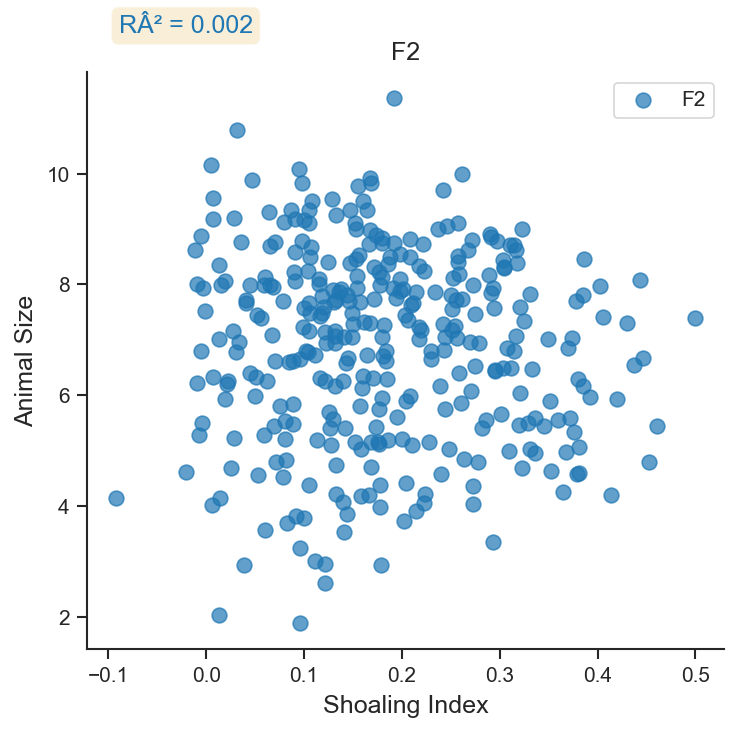

In [74]:
from scipy import stats

# Correlation between SI and animal size
ix = (dfEpiAn.episode == '02k20f') & (dfEpiAn.genotype == 'F2')

data_for_plot = dfEpiAn[ix].groupby(['animalIndex','genotype']).mean(numeric_only=True).reset_index()

# Drop columns with missing data on the anSize column
data_for_plot = data_for_plot.dropna(subset=['anSize'])

# Define custom colors for each genotype
custom_palette = {'F2': "#1F77B4", 'o': "#25B66D"}  

# Increase font sizes for this plot
#font_scale = 1.3
#sns.set_context("notebook", font_scale=font_scale)

g=sns.FacetGrid(data_for_plot, col='genotype', hue='genotype', palette=custom_palette, height=5)

# Create a counter to track which setup we're plotting
call_count = [0]

def plot_with_regression(x, y, **kwargs):
    # Get the color from kwargs
    color = kwargs.get('color', 'C0')
    
    # Scatter plot
    plt.scatter(x, y, s=50, alpha=0.7, **kwargs)
    
    # Add regression line and calculate RÂ²
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value**2
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    #plt.plot(x_line, y_line, **kwargs, linewidth=2)
    
    # Position labels above the plot area to avoid blocking data points
    # First setup at 1.10, second setup at 1.00
    # y_pos = 1.20 if call_count[0] % 2 == 0 else 1.10
    # call_count[0] += 1
    y_pos = 1.10
    x_pos = 0.1
    
    # Add RÂ² text annotation outside the plot area
    plt.text(0.05, y_pos, f'RÂ² = {r_squared:.3f}', 
             transform=plt.gca().transAxes, 
             verticalalignment='top',
             color=color,
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

g.map(plot_with_regression, 'si', 'anSize')

g.set_axis_labels('Shoaling Index', 'Animal Size', fontsize=12)
g.set_titles(col_template="{col_name}", size=12)
for ax in g.axes.flat:
    ax.tick_params(labelsize=10)

plt.legend(fontsize=10, title_fontsize=10)

data_for_plot



### Fish speed across experiments

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


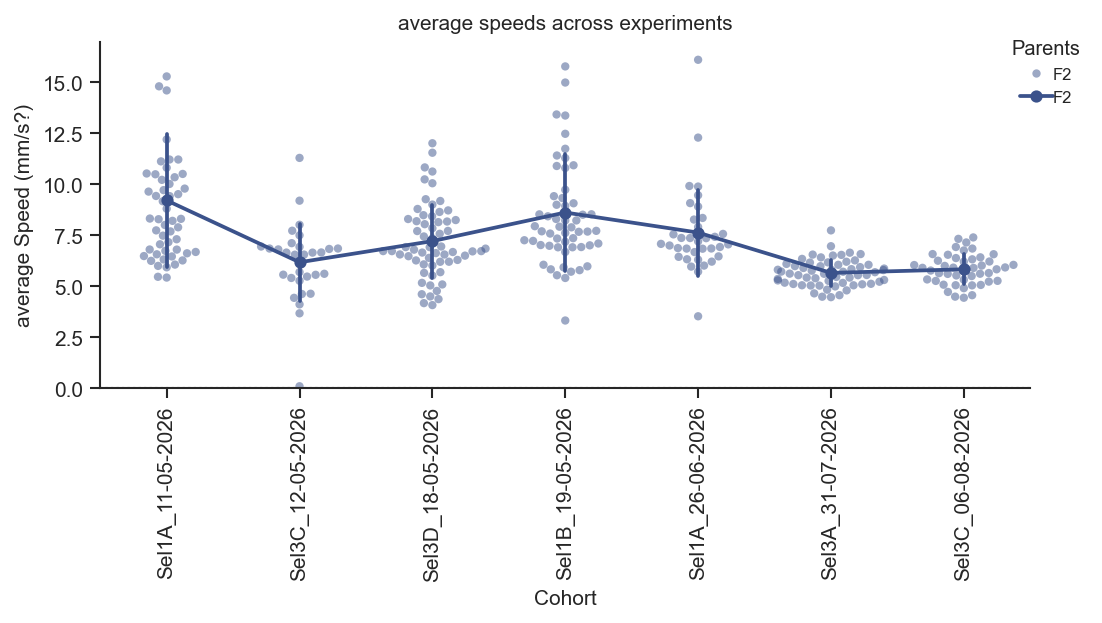

In [75]:
fig, axes = plt.subplots(figsize=(8, 3))
#ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo'))
#ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo'))&(dfEpiAn.avgSpeed<10) #filter extreme speed values
ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='F2')

selDat=dfEpiAn[ix]

show_lines = "All" 
#show_lines = [ "Sel1_10", "Sel1_11"]  # set the lines you want to keep

if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='avgSpeed',
              hue='genotype',
              zorder=-1,
              dodge=.5,
              size=4,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             hue_order=["F2"])

sns.pointplot(data=selDat,
              x='lineSet',
              y='avgSpeed',
              hue='genotype',
              #dodge=.5,
              linestyle='-',
              errorbar='sd',
              #hue_order=["hi", "lo",'wt','esc','mid'])
              hue_order=["F2"])


sns.despine()

axes.set_ylabel('average Speed (mm/s?)')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

axes.set_ylim(0, 17)

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1.07, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('average speeds across experiments');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "avgSpeed_hivslo.pdf"), bbox_inches="tight")


### Thimogtaxis across experiments

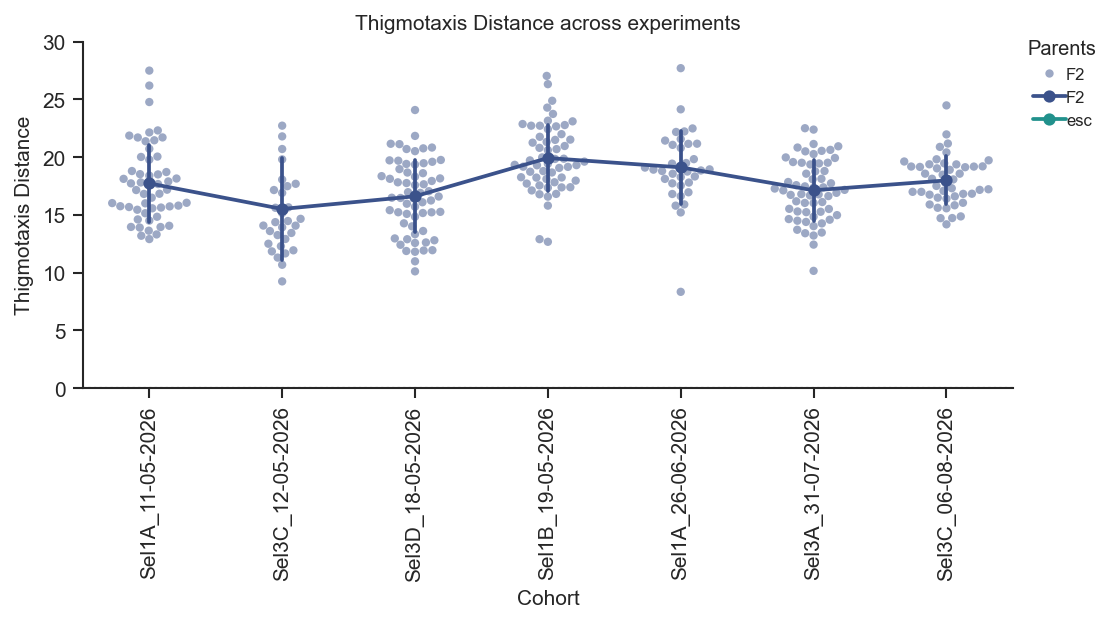

In [76]:
fig, axes = plt.subplots(figsize=(8, 3))
#ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo'))#&(~dfEpiAn.lineSet.str.contains('_2_'))
ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='F2')

selDat=dfEpiAn[ix]

show_lines = "All" 
#show_lines = [ "Sel1_10", "Sel1_11"]  # set the lines you want to keep

if show_lines != "All":
    selDat = selDat[selDat['line'].isin(show_lines)]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='thigmoIndex',
              hue='genotype',
              zorder=-1,
              dodge=.5,
              size=4,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             hue_order=["F2"])

sns.pointplot(data=selDat,
              x='lineSet',
              y='thigmoIndex',
              hue='genotype',
              linestyle='-',
              errorbar='sd',
              hue_order=["F2", "esc"]
              #hue_order=["hi",'esc_hi', "lo",'esc_lo','wt','mid'])
)

sns.despine()

axes.set_ylabel('Thigmotaxis Distance')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');
axes.set_ylim(0, 30)

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Thigmotaxis Distance across experiments');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "thigmoIndex_hivslo.pdf"), bbox_inches="tight")

### Correlations of speed with other metrics

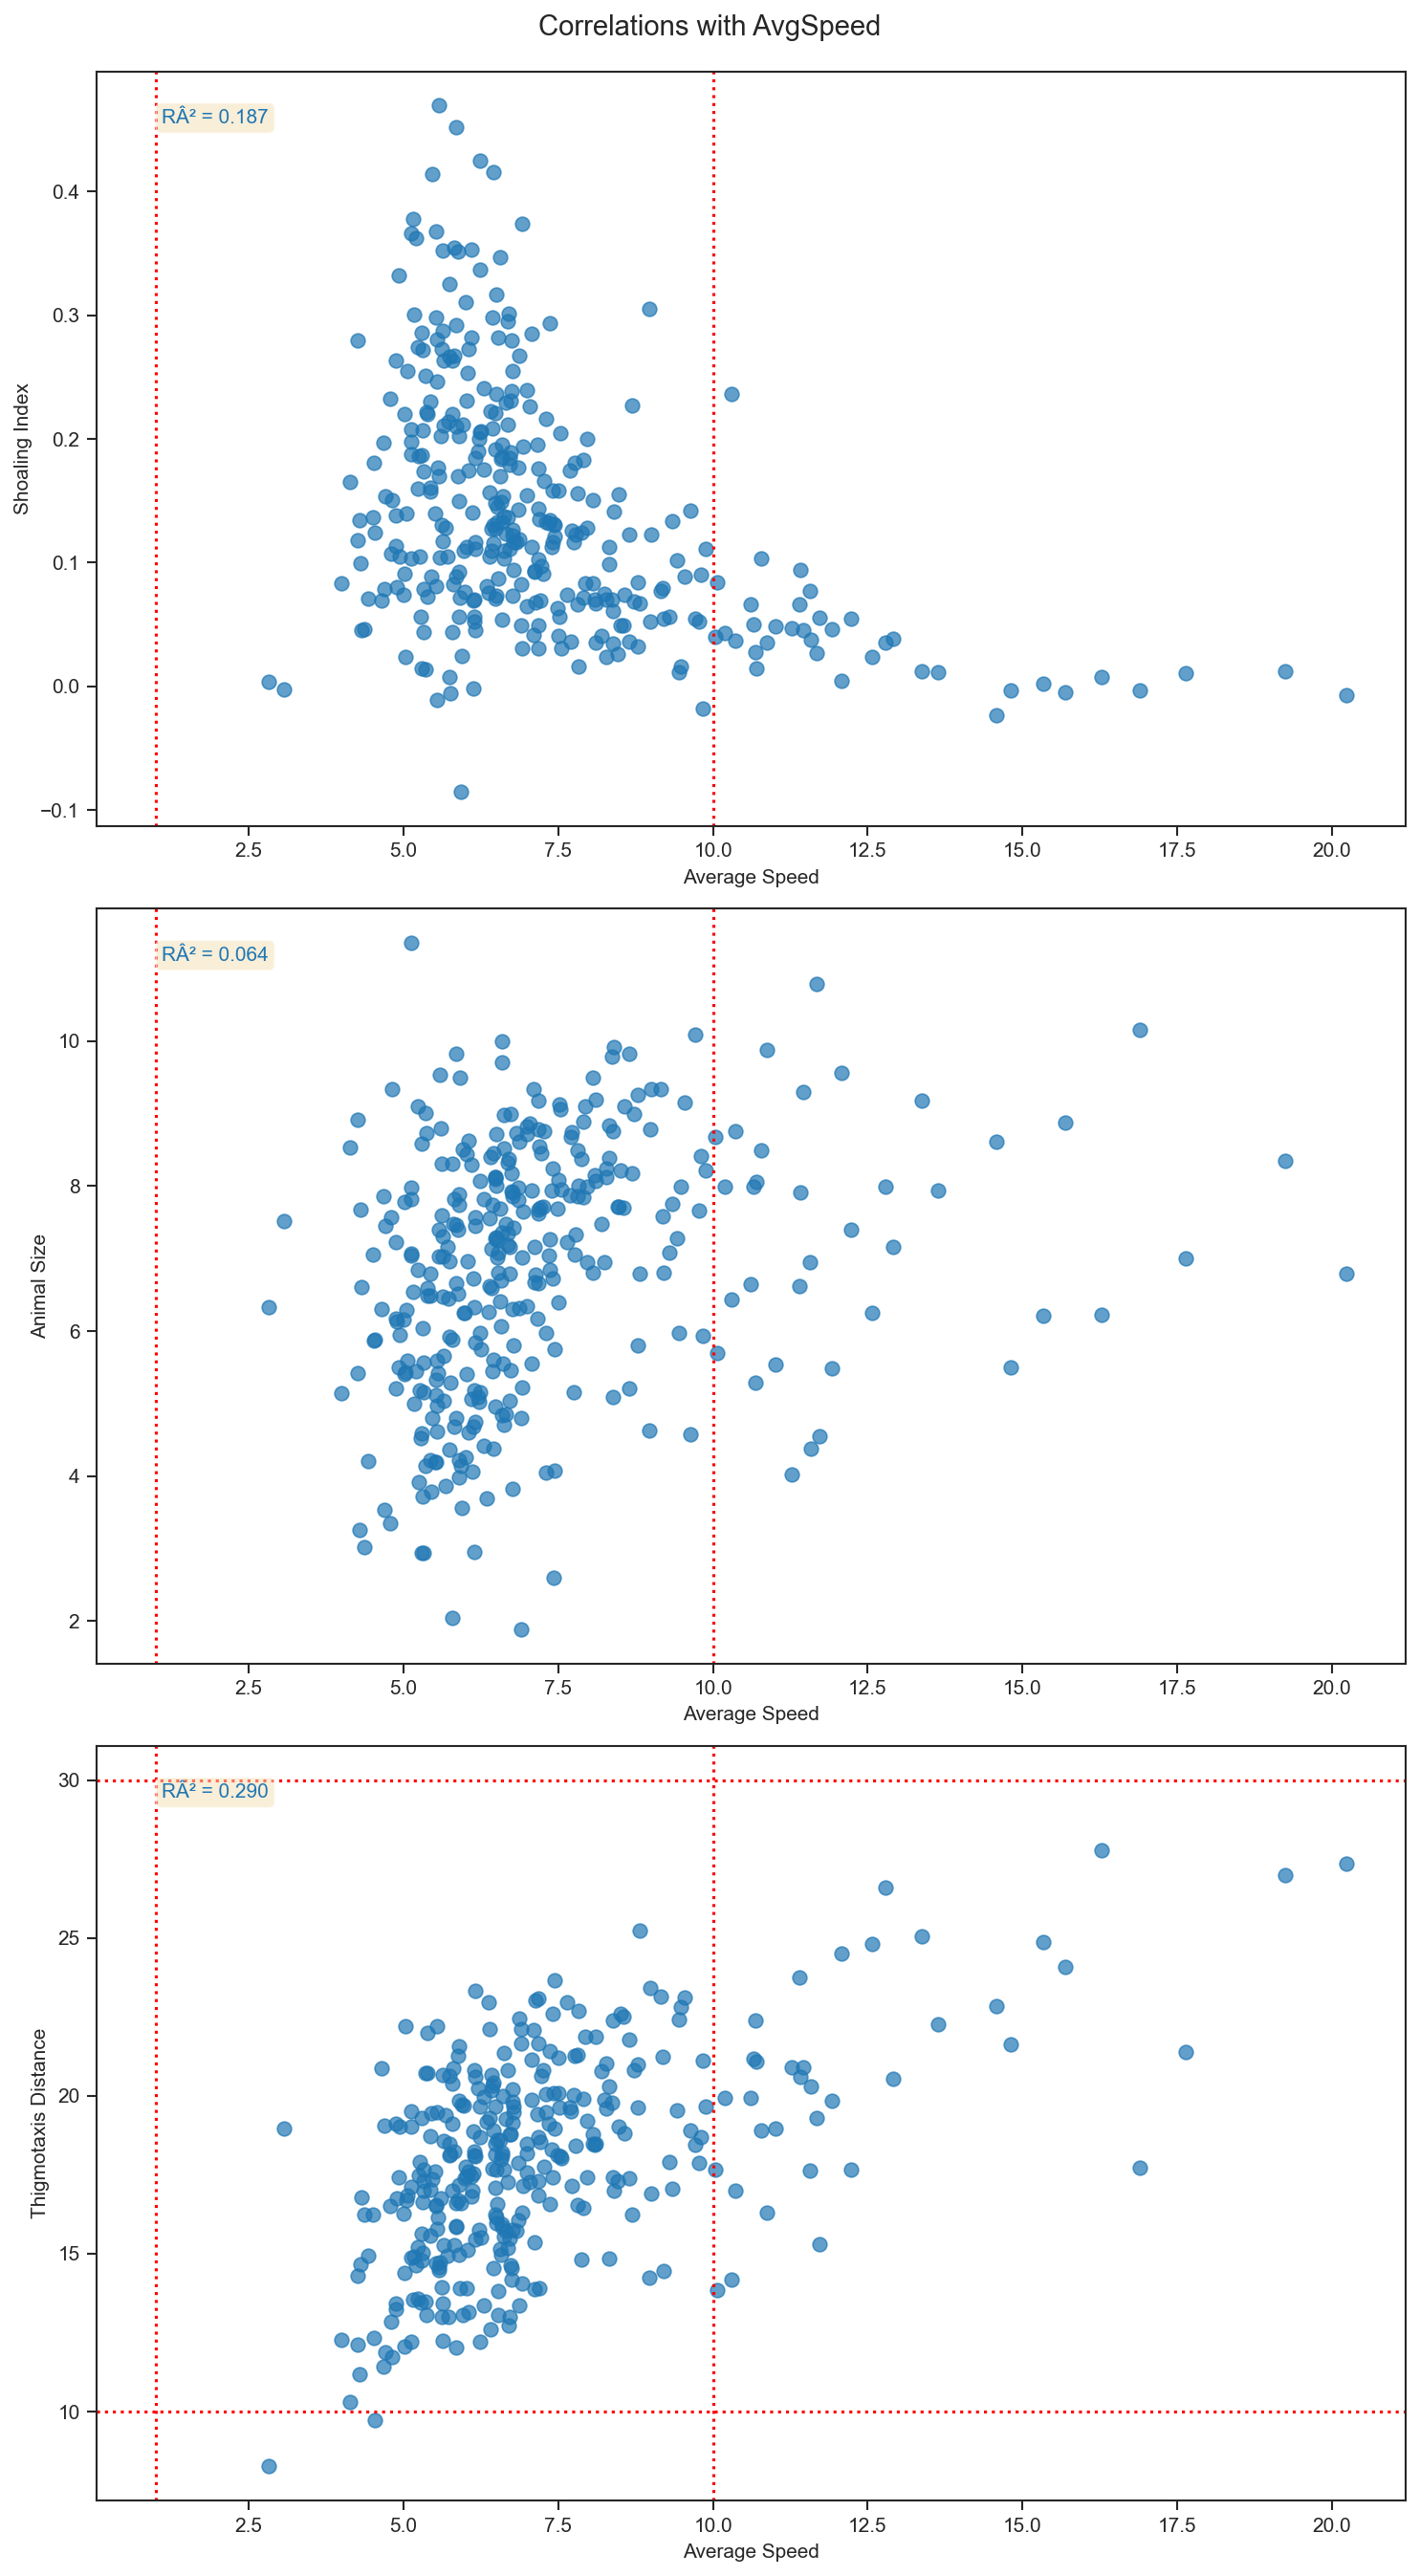

In [77]:
from scipy import stats

# Correlation between SI and average speed

#Correlation between SI and animal size
#ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='F2')
ix=(dfEpiAn.genotype!='na') #include all genotypes except NA



data_for_plot = dfEpiAn[ix].groupby(['animalIndex','genotype']).mean(numeric_only=True).reset_index()

# Drop columns with missing data on the anSize column
data_for_plot = data_for_plot.dropna(subset=['anSize'])


# Define custom colors for each genotype
custom_palette = {'F2': "#1F77B4", 'esc': "#25B66D"}  

# Define the comparisons (three panels: add thigmotaxis vs speed)
comparisons = [
    ('avgSpeed', 'si', 'Average Speed', 'Shoaling Index'),
    ('avgSpeed', 'anSize', 'Average Speed', 'Animal Size'),
    ('avgSpeed', 'thigmoIndex', 'Average Speed', 'Thigmotaxis Distance')
]

# Genotypes to plot
genotypes = ['F2']

# Thresholds for avg speed (vertical lines)
max_speed = 10
min_speed = 1

# Thresholds for thigmotaxis (when plotted on y-axis)
max_thigmoIndex = 30
min_thigmoIndex = 10

# Create a vertical figure with one row per comparison to avoid empty axes
nrows = len(comparisons)
fig, axes = plt.subplots(nrows, 1, figsize=(10, 6 * nrows))
axes = np.atleast_1d(axes)
fig.suptitle('Correlations with AvgSpeed', fontsize=14, y=0.995)

for row_idx, (x_var, y_var, x_label, y_label) in enumerate(comparisons):
    ax = axes[row_idx]
    for genotype in genotypes:
        # Filter data for this genotype
        geno_data = data_for_plot[data_for_plot['genotype'] == genotype]
        color = custom_palette.get(genotype, 'C0')
        
        # Scatter plot
        ax.scatter(geno_data[x_var], geno_data[y_var], s=50, alpha=0.7, color=color)
        
        # Add regression line and calculate RÂ²
        if len(geno_data) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(geno_data[x_var], geno_data[y_var])
            r_squared = r_value**2
            x_line = np.linspace(geno_data[x_var].min(), geno_data[x_var].max(), 100)
            y_line = slope * x_line + intercept
            #ax.plot(x_line, y_line, color=color, linewidth=2)
        else:
            r_squared = np.nan

        # Add RÂ² text annotation
        ax.text(0.05, 0.95, f'RÂ² = {r_squared:.3f}' if np.isfinite(r_squared) else 'RÂ² = N/A', 
                transform=ax.transAxes, 
                verticalalignment='top',
                color=color,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Add vertical threshold lines for avgSpeed when plotted on x-axis
    ax.axvline(min_speed, color='red', linestyle=':', linewidth=1.5)
    ax.axvline(max_speed, color='red', linestyle=':', linewidth=1.5)

    # If plotting thigmotaxis on the y-axis, add horizontal threshold lines
    if y_var == 'thigmoIndex':
        ax.axhline(min_thigmoIndex, color='red', linestyle=':', linewidth=1.5)
        ax.axhline(max_thigmoIndex, color='red', linestyle=':', linewidth=1.5)

    # Add axis labels
    ax.set_ylabel(y_label)
    ax.set_xlabel(x_label)
    ax.set_title('', fontsize=12)

plt.tight_layout()
plt.show()


## Correlations of SI with other metrics per lineSet

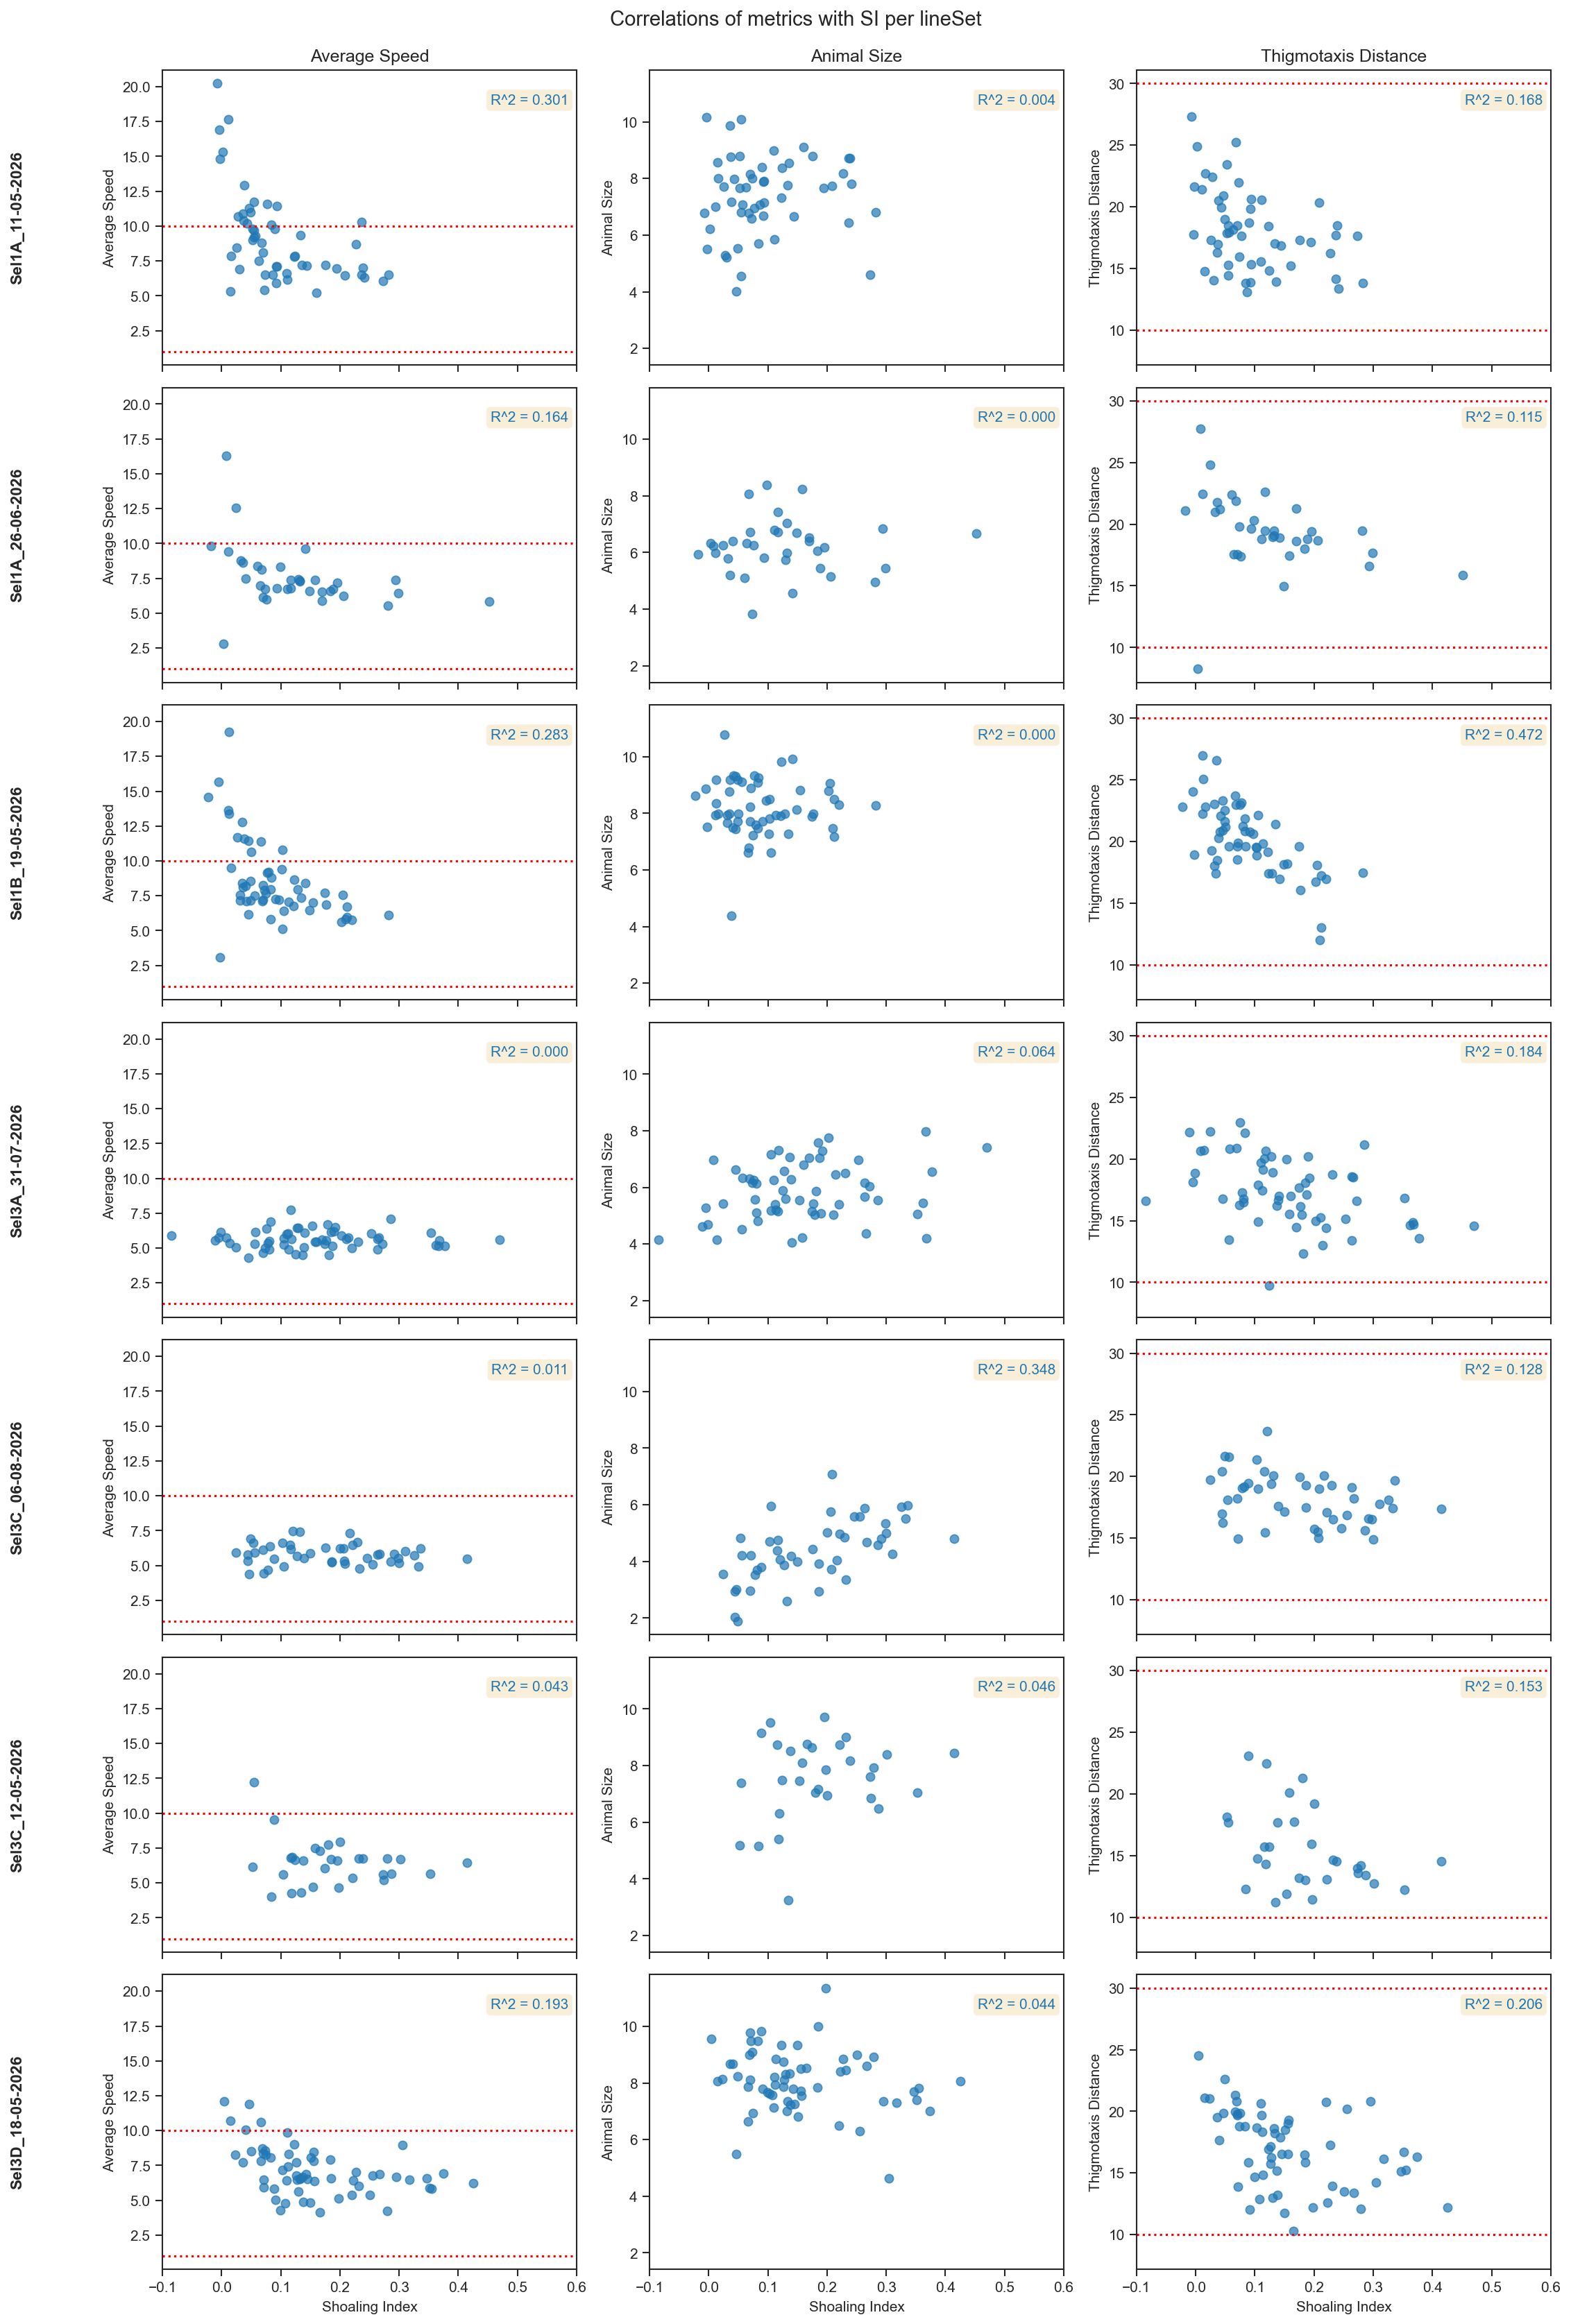

In [78]:
# Correlations with SI, split into one row per lineSet.
si_line_set_comparisons = [
    ('si', 'avgSpeed', 'Shoaling Index', 'Average Speed'),
    ('si', 'anSize', 'Shoaling Index', 'Animal Size'),
    ('si', 'thigmoIndex', 'Shoaling Index', 'Thigmotaxis Distance')
]

# Hard-coded threshold guides for the grid plot.
max_speed = 10
min_speed = 1
max_thigmoIndex = 30
min_thigmoIndex = 10


si_xlim = (-0.1, 0.6)  # change to whatever range you want


line_set_data = (
    dfEpiAn[ix]
    .groupby(['animalIndex', 'genotype', 'lineSet'])
    .mean(numeric_only=True)
    .reset_index()
)

line_set_data = line_set_data.dropna(subset=['anSize', 'thigmoIndex', 'avgSpeed', 'si'])
line_sets = sorted(line_set_data['lineSet'].dropna().unique())
si_line_set_genotypes = [
    genotype for genotype in genotypes
    if genotype in line_set_data['genotype'].dropna().unique()
]

nrows = len(line_sets)
ncols = len(si_line_set_comparisons)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 3.2 * nrows),
    sharex='col',
    sharey='col',
    squeeze=False
)
fig.suptitle('Correlations of metrics with SI per lineSet', fontsize=14, y=0.995)

for row_idx, line_set in enumerate(line_sets):
    for col_idx, (x_var, y_var, x_label, y_label) in enumerate(si_line_set_comparisons):
        ax = axes[row_idx, col_idx]
        for genotype_idx, genotype in enumerate(si_line_set_genotypes):
            plot_data = line_set_data[
                (line_set_data['lineSet'] == line_set)
                & (line_set_data['genotype'] == genotype)
            ].dropna(subset=[x_var, y_var])
            color = custom_palette.get(genotype, 'C0')

            ax.scatter(plot_data[x_var], plot_data[y_var], s=35, alpha=0.7, color=color)

            if (
                len(plot_data) > 1
                and plot_data[x_var].nunique() > 1
                and plot_data[y_var].nunique() > 1
            ):
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    plot_data[x_var], plot_data[y_var]
                )
                r_squared = r_value**2
            else:
                r_squared = np.nan

            r_squared_label = f'R^2 = {r_squared:.3f}' if np.isfinite(r_squared) else 'R^2 = N/A'
            if len(si_line_set_genotypes) > 1:
                r_squared_label = f'{genotype}: {r_squared_label}'

            ax.text(
                0.98,
                0.92 - 0.12 * genotype_idx,
                r_squared_label,
                transform=ax.transAxes,
                verticalalignment='top',
                horizontalalignment='right',
                color=color,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )

        if y_var == 'avgSpeed':
            ax.axhline(min_speed, color='red', linestyle='dotted', linewidth=1.5)
            ax.axhline(max_speed, color='red', linestyle='dotted', linewidth=1.5)

        if y_var == 'thigmoIndex':
            ax.axhline(min_thigmoIndex, color='red', linestyle='dotted', linewidth=1.5)
            ax.axhline(max_thigmoIndex, color='red', linestyle='dotted', linewidth=1.5)

        if row_idx == 0:
            ax.set_title(y_label, fontsize=12)
        if row_idx == nrows - 1:
            ax.set_xlabel(x_label)
        else:
            ax.set_xlabel('')

        ax.set_ylabel(y_label)
        ax.set_xlim(si_xlim)
        if col_idx == 0:
            ax.text(
                -0.35,
                0.5,
                line_set,
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=11,
                fontweight='bold'
            )

plt.tight_layout()
plt.show()


# F2s vs selected lines metrics comparisons

## Importing data from selection lines experiments

In [79]:
#Import data from selection experiments for comparison
selDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/'
SelEpiAn = pd.read_csv(os.path.join(selDir, 'dfEpiAn_selection.csv'))

# Create a new column to indicate the dataset (F2 vs selection)
temp_dfEpiAn = dfEpiAn.copy()
temp_dfEpiAn['dataset'] = "F2"
SelEpiAn['dataset'] = "Selection"


# Combine the selection data with the current dataset for comparison
comboEpiAn = pd.concat([temp_dfEpiAn, SelEpiAn], ignore_index=True)




comboEpiAn['animalIndex'] = comboEpiAn['animalIndex'].astype(str) + "_" + comboEpiAn['dataset']

comboEpiAn.genotype.unique()

array(['F2', 'esc', 'hi', 'lo', 'esc_lo', 'esc_hi', 'na'], dtype=object)

In [80]:
comboEpiAn

,episode,animalIndex,line,setup,genotype,date,lineSet,animalSet,animalID,CurrentPartner,...,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr,dataset,Unnamed: 0
0,01k01f,1_F2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,0.0,35.0,...,6.337527,7.329442,18.317183,0.816667,0.0,0.0,0.0,1.0,F2,NaN
1,01k01f,2_F2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,1.0,35.0,...,5.325227,7.654782,17.126884,0.666667,0.0,0.0,0.0,2.0,F2,NaN
2,01k01f,3_F2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,2.0,35.0,...,11.212608,6.947497,18.767604,0.566667,0.0,0.0,0.0,3.0,F2,NaN
3,01k01f,4_F2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,3.0,35.0,...,8.846323,4.022061,19.947904,0.733333,0.0,0.0,0.0,4.0,F2,NaN
4,01k01f,5_F2,Sel1A,1,F2,11-05-2026,Sel1A_11-05-2026,0.0,4.0,35.0,...,4.427094,5.845555,21.168090,0.816667,0.0,0.0,0.0,5.0,F2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,02k20f,1046_Selection,Sel1_GC8,2,lo,07-05-2026,Sel1_GC8_07-05-2026,29.0,30.0,35.0,...,7.712842,2.713178,23.503155,0.613333,0.0,0.0,0.0,1046.0,Selection,2095.0
2912,02k20f,1047_Selection,Sel1_GC8,2,hi,07-05-2026,Sel1_GC8_07-05-2026,29.0,31.0,35.0,...,16.044767,3.255814,24.445794,0.666667,0.0,0.0,0.0,1047.0,Selection,2096.0
2913,02k20f,1048_Selection,Sel1_GC8,2,lo,07-05-2026,Sel1_GC8_07-05-2026,29.0,32.0,35.0,...,7.912161,3.428273,23.428503,0.613333,0.0,0.0,0.0,1048.0,Selection,2097.0
2914,02k20f,1049_Selection,Sel1_GC8,2,hi,07-05-2026,Sel1_GC8_07-05-2026,29.0,33.0,35.0,...,4.356902,3.837014,13.473636,0.813333,0.0,0.0,0.0,1049.0,Selection,2098.0


## Correlation of metrics *per genotype*

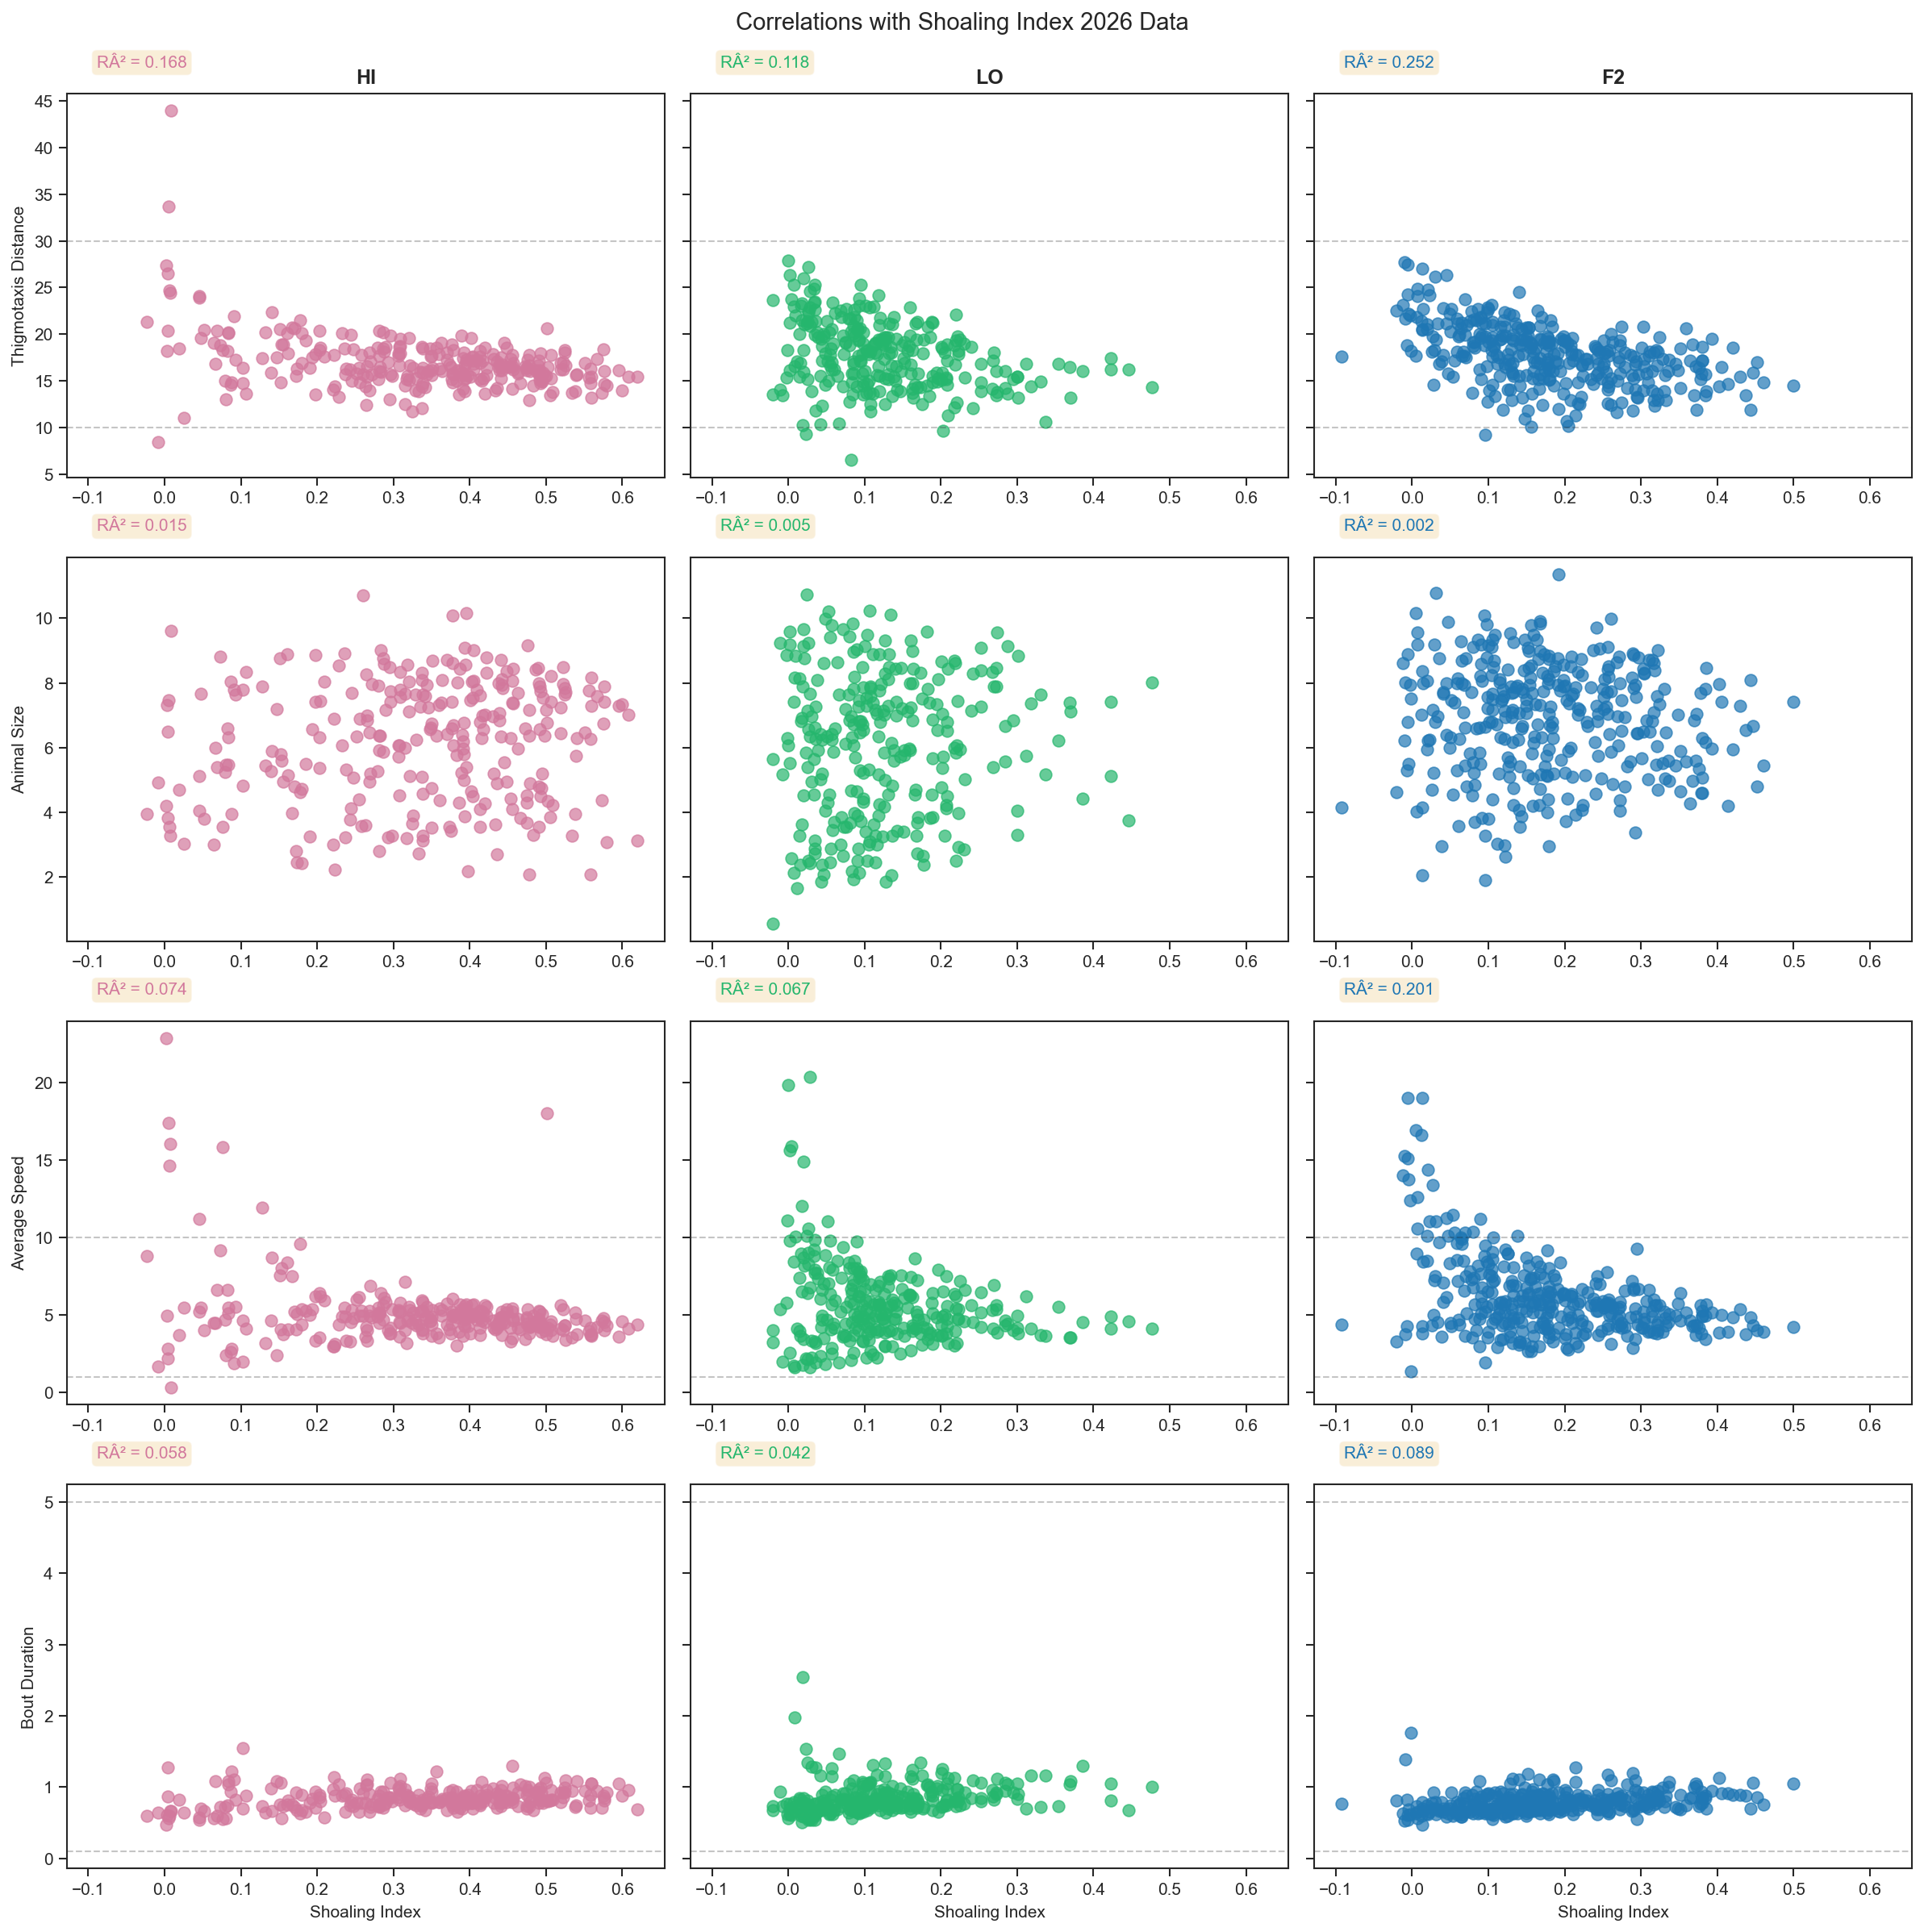

In [81]:
# Correlation between SI and all the others




#Data filtering settings

comboEpiAn['date'] = pd.to_datetime(comboEpiAn['date'], format='%d-%m-%Y', dayfirst=True, errors='coerce') # Convert date column to datetime, coercing errors to NaT for invalid formats

exclude_date1 = pd.Timestamp('2025-12-31')
exclude_date2 = pd.Timestamp('2025-07-28')

ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    & (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    #& (comboEpiAn['date'] >= exclude_date1) #only include experiments from 2026, when the setup was stable and optimized
    #& (comboEpiAn['date'] <= exclude_date2) #only include experiments from early 2025
    & ((comboEpiAn['date'] <= exclude_date2) | (comboEpiAn['date'] >= exclude_date1)) #only include experiments from 2026, or from early 2025, when the setup was stable
)



# ix=(
#     (comboEpiAn.episode=='02k20f') #only use shoaling attraction to bout-like stimulus
#     &((comboEpiAn.genotype=='F2') | (comboEpiAn.genotype=='hi') | (comboEpiAn.genotype=='lo')) # keep all genotypes but exclude na's or escapees from analysis
#     &(comboEpiAn.boutDur<4) #filter extreme bout duration values
#     &(comboEpiAn.date >= exclude_date) #only include experiments from 2026, when the setup was stable and optimized
# )

data_for_plot = comboEpiAn[ix].groupby(['animalIndex','genotype']).mean(numeric_only=True).reset_index()

# Drop columns with missing data on the anSize or thigmoIndex column
data_for_plot = data_for_plot.dropna(subset=['anSize', 'thigmoIndex', 'boutDur'])

# Define custom colors for each genotype
custom_palette = {'hi': "#D2789C", 'lo': "#25B66D", 'F2': "#1F77B4"}  

# Thresholds (used as dotted red lines)
max_speed = 10
min_speed = 1
max_boutDur = 5
min_boutDur = 0.1
max_thigmoIndex = 30
min_thigmoIndex = 10

# Create a single figure with subplots (4 rows x 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(16, 16), sharex='row', sharey='row')
fig.suptitle('Correlations with Shoaling Index 2026 Data', fontsize=14, y=0.995)

# Define the four comparisons
comparisons = [
    ('si', 'thigmoIndex', 'Shoaling Index', 'Thigmotaxis Distance'),
    ('si', 'anSize', 'Shoaling Index', 'Animal Size'),
    ('si', 'avgSpeed_smooth', 'Shoaling Index', 'Average Speed'),
    ('si', 'boutDur', 'Shoaling Index', 'Bout Duration')
]

genotypes = ['hi', 'lo', 'F2']  # Include F2 for comparison
#axes = axes.flatten()

# for ax, (x_var, y_var, x_label, y_label) in zip(axes, comparisons):
#     for genotype in genotypes:
#         # Filter data for this genotype
#         geno_data = data_for_plot[data_for_plot['genotype'] == genotype]
#         color = custom_palette[genotype]
        
#         # Scatter plot
#         ax.scatter(geno_data[x_var], geno_data[y_var], s=50, alpha=0.7, color=color)
        
#         # Add regression line and calculate RÂ²
#         slope, intercept, r_value, p_value, std_err = stats.linregress(geno_data[x_var], geno_data[y_var])
#         r_squared = r_value**2
#         x_line = np.linspace(geno_data[x_var].min(), geno_data[x_var].max(), 100)
#         y_line = slope * x_line + intercept
#         #ax.plot(x_line, y_line, color=color, linewidth=2)
        
#         # Add RÂ² text annotation
#         ax.text(0.05, 1.10, f'RÂ² = {r_squared:.3f}', 
#                 transform=ax.transAxes, 
#                 verticalalignment='top',
#                 color=color,
#                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
#         # Add threshold lines where relevant
#         if x_var in ('avgSpeed_smooth', 'avgSpeed'):
#             ax.axvline(min_speed, color='red', linestyle=':', linewidth=1.5)
#             ax.axvline(max_speed, color='red', linestyle=':', linewidth=1.5)
#         if y_var in ('avgSpeed_smooth', 'avgSpeed'):
#             ax.axhline(min_speed, color='red', linestyle=':', linewidth=1.5)
#             ax.axhline(max_speed, color='red', linestyle=':', linewidth=1.5)
#         if x_var == 'boutDur':
#             ax.axvline(min_boutDur, color='red', linestyle=':', linewidth=1.5)
#             ax.axvline(max_boutDur, color='red', linestyle=':', linewidth=1.5)
#         if y_var == 'boutDur':
#             ax.axhline(min_boutDur, color='red', linestyle=':', linewidth=1.5)
#             ax.axhline(max_boutDur, color='red', linestyle=':', linewidth=1.5)
#         if x_var == 'thigmoIndex':
#             ax.axvline(min_thigmoIndex, color='red', linestyle=':', linewidth=1.5)
#             ax.axvline(max_thigmoIndex, color='red', linestyle=':', linewidth=1.5)
#         if y_var == 'thigmoIndex':
#             ax.axhline(min_thigmoIndex, color='red', linestyle=':', linewidth=1.5)
#             ax.axhline(max_thigmoIndex, color='red', linestyle=':', linewidth=1.5)
        
#         ax.set_ylabel(y_label)
#         ax.set_xlabel(x_label)
#         ax.set_title(f'{genotype.upper()}', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.show()

for row_idx, (x_var, y_var, x_label, y_label) in enumerate(comparisons):
    for col_idx, genotype in enumerate(genotypes):
        ax = axes[row_idx, col_idx]
        
        # Filter data for this genotype
        geno_data = data_for_plot[data_for_plot['genotype'] == genotype]
        color = custom_palette[genotype]
        
        # Scatter plot
        ax.scatter(geno_data[x_var], geno_data[y_var], s=50, alpha=0.7, color=color)
        
        # Threshold guides for the variables used in the filtering step
        if y_var == 'thigmoIndex':
            ax.axhline(min_thigmoIndex, ls='--', color='k', alpha=0.25, linewidth=1)
            ax.axhline(max_thigmoIndex, ls='--', color='k', alpha=0.25, linewidth=1)
        elif y_var == 'avgSpeed_smooth':
            ax.axhline(min_speed, ls='--', color='k', alpha=0.25, linewidth=1)
            ax.axhline(max_speed, ls='--', color='k', alpha=0.25, linewidth=1)
        elif y_var == 'boutDur':
            ax.axhline(min_boutDur, ls='--', color='k', alpha=0.25, linewidth=1)
            ax.axhline(max_boutDur, ls='--', color='k', alpha=0.25, linewidth=1)
        
        # Add regression line and calculate RÂ²
        slope, intercept, r_value, p_value, std_err = stats.linregress(geno_data[x_var], geno_data[y_var])
        r_squared = r_value**2
        x_line = np.linspace(geno_data[x_var].min(), geno_data[x_var].max(), 100)
        y_line = slope * x_line + intercept
        #ax.plot(x_line, y_line, color=color, linewidth=2)
        
        # Add RÂ² text annotation
        ax.text(0.05, 1.10, f'RÂ² = {r_squared:.3f}', 
                transform=ax.transAxes, 
                verticalalignment='top',
                color=color,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Set labels and title
        if row_idx == 0:
            ax.set_title(f'{genotype.upper()}', fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(y_label)
        if row_idx == len(comparisons) - 1:
            ax.set_xlabel(x_label)

plt.tight_layout()
plt.show()


## Comparison of metrics *per genotype*

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.war

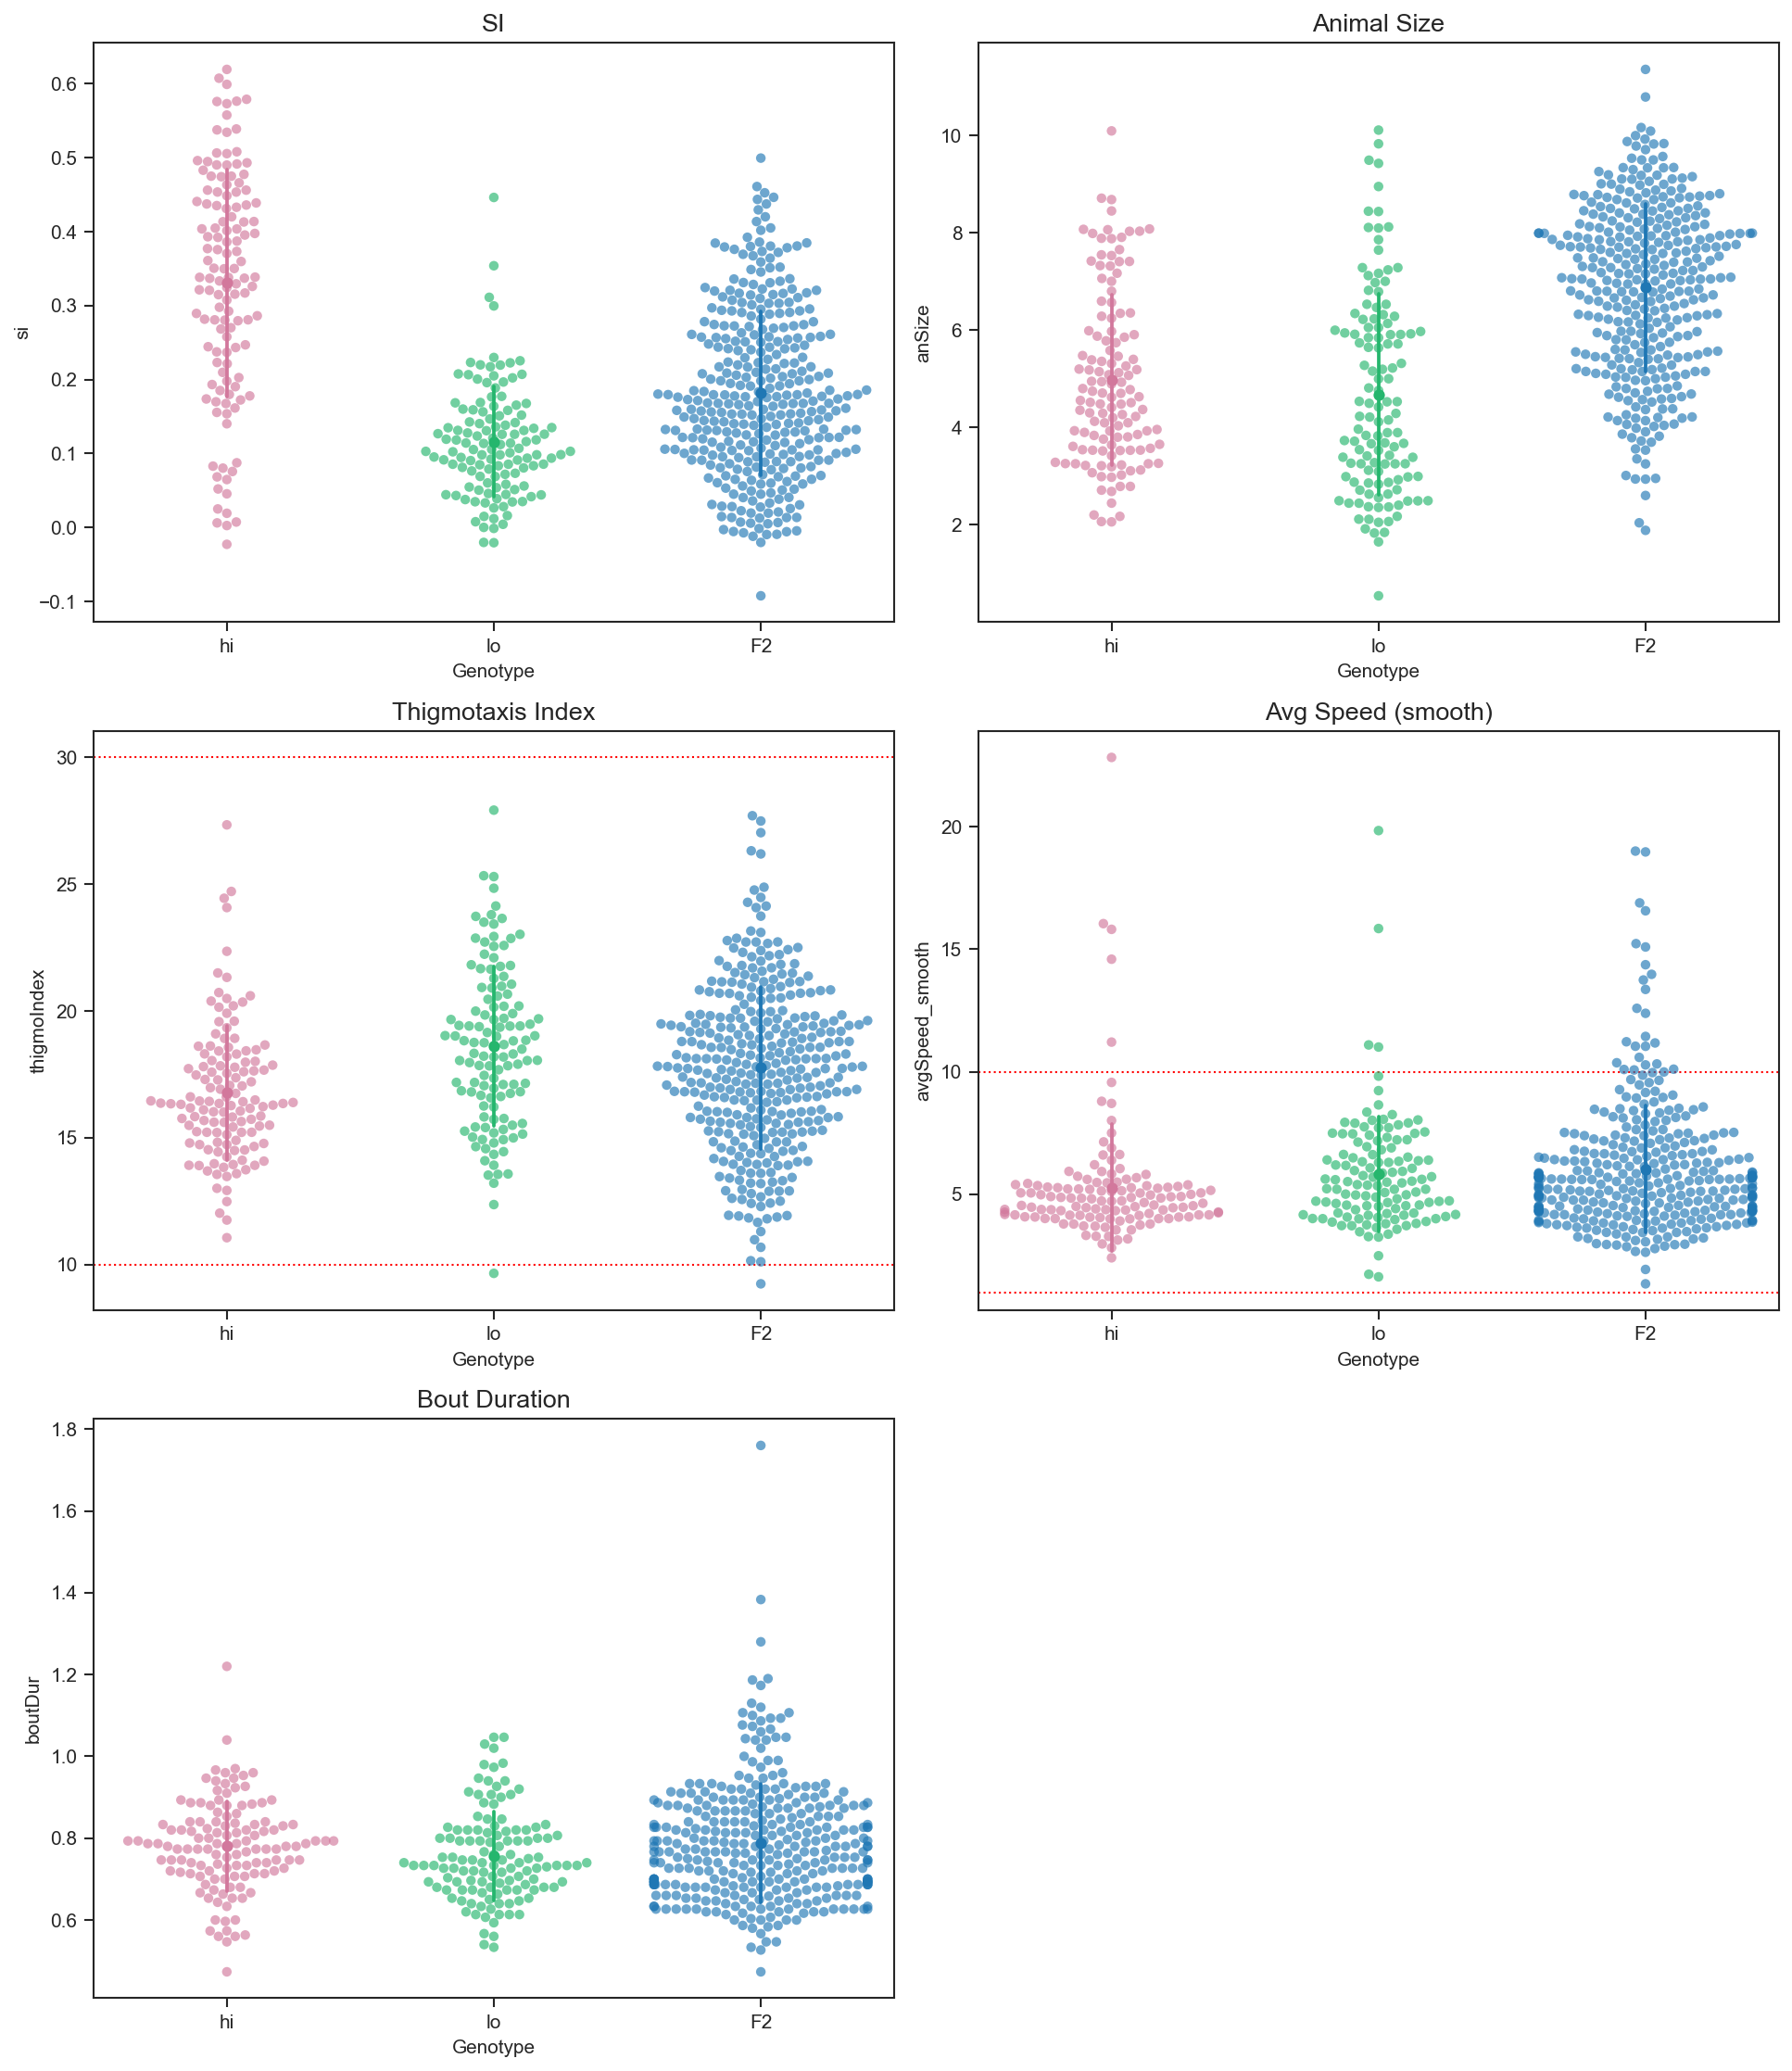

,animalIndex,genotype,setup,animalSet,animalID,CurrentPartner,si,epStart,inDishTime,epiNr,...,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr,Unnamed: 0
0,1000_Selection,lo,1.0,28.0,19.0,35.0,0.223205,171000.0,105.0,19.0,...,6.023480,4.732178,2.926864,17.842369,0.853333,0.0,0.0,0.0,1000.0,2049.0
1,1001_Selection,hi,1.0,28.0,20.0,35.0,0.456235,171000.0,105.0,19.0,...,6.257650,5.201742,4.097479,14.114317,0.793333,0.0,0.0,0.0,1001.0,2050.0
2,1002_Selection,lo,1.0,28.0,21.0,35.0,0.101053,171000.0,105.0,19.0,...,7.152835,5.934286,3.389445,23.024805,0.696667,0.0,0.0,0.0,1002.0,2051.0
3,1003_Selection,hi,1.0,28.0,22.0,35.0,0.493198,171000.0,105.0,19.0,...,5.202763,4.214209,4.484184,14.730796,0.840000,0.0,0.0,0.0,1003.0,2052.0
4,1004_Selection,lo,1.0,28.0,23.0,35.0,0.142731,171000.0,105.0,19.0,...,4.916735,3.798064,3.415683,14.095765,0.883333,0.0,0.0,0.0,1004.0,2053.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,996_Selection,lo,1.0,28.0,15.0,35.0,0.016119,171000.0,105.0,19.0,...,5.120152,3.638464,2.367853,16.952606,0.750000,0.0,0.0,0.0,996.0,2045.0
594,997_Selection,hi,1.0,28.0,16.0,35.0,0.019228,171000.0,105.0,19.0,...,5.063049,3.697932,4.701513,18.427992,0.820000,0.0,0.0,0.0,997.0,2046.0
595,998_Selection,lo,1.0,28.0,17.0,35.0,0.205121,171000.0,105.0,19.0,...,6.223843,5.006160,3.266667,18.047885,0.753333,0.0,0.0,0.0,998.0,2047.0
596,999_Selection,hi,1.0,28.0,18.0,35.0,-0.022757,171000.0,105.0,19.0,...,9.808834,8.794130,3.931456,21.326044,0.600000,0.0,0.0,0.0,999.0,2048.0


In [82]:
# Boxplot of Hi vs Lo vs F2 for the 4 variables



# -----------------------------
# Data filtering settings
# -----------------------------
comboEpiAn['date'] = pd.to_datetime(
    comboEpiAn['date'],
    format='%d-%m-%Y',
    dayfirst=True,
    errors='coerce'
)

exclude_date1 = pd.Timestamp('2025-12-31')
exclude_date2 = pd.Timestamp('2025-07-28')

ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    & (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    & (comboEpiAn['date'] >= exclude_date1) #only include experiments from 2026, when the setup was stable and optimized
    #& (comboEpiAn['date'] <= exclude_date2) #only include experiments from early 2025
    #& ((comboEpiAn['date'] <= exclude_date2) | (comboEpiAn['date'] >= exclude_date1)) #only include experiments from 2026, or from early 2025, when the setup was stable
)

data_for_plot = (
    comboEpiAn[ix]
    .groupby(['animalIndex', 'genotype'])
    .mean(numeric_only=True)
    .reset_index()
)

# Drop missing values
data_for_plot = data_for_plot.dropna(
    subset=['anSize', 'thigmoIndex', 'boutDur', 'si', 'avgSpeed_smooth']
)

# -----------------------------
# Plot settings
# -----------------------------
custom_palette = {'hi': "#D2789C", 'lo': "#25B66D", 'F2': "#1F77B4"}
order = ['hi', 'lo', 'F2']

variables = ['si', 'anSize', 'thigmoIndex', 'avgSpeed_smooth', 'boutDur']
titles = ['SI', 'Animal Size', 'Thigmotaxis Index', 'Avg Speed (smooth)', 'Bout Duration']

# Optional thresholds
thresholds = {
    'avgSpeed_smooth': [1, 10],
    'thigmoIndex': [10, 30]
}

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(13, 15))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[i]

    # Mean Â± SD (pointplot)
    sns.pointplot(
        data=data_for_plot,
        x='genotype',
        y=var,
        linestyle='none',
        errorbar='sd',
        order=order,
        #palette=custom_palette,
        hue='genotype',
         palette=custom_palette,
        ax=ax
    )

    # Individual points (swarm)
    sns.swarmplot(
        data=data_for_plot,
        x='genotype',
        y=var,
        size=5,
        alpha=0.65,
        order=order,
        hue='genotype',
        palette=custom_palette,
        ax=ax
    )

    # Threshold lines if defined
    if var in thresholds:
        for y in thresholds[var]:
            ax.axhline(y, color='red', linestyle='dotted', linewidth=1)

    # Labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Genotype')
    ax.set_ylabel(var)

# Remove unused last subplot (6th slot)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

data_for_plot

## Comparison of metrics *per experiment*

### Comparison of the different metrics across all Sel1 experiments

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

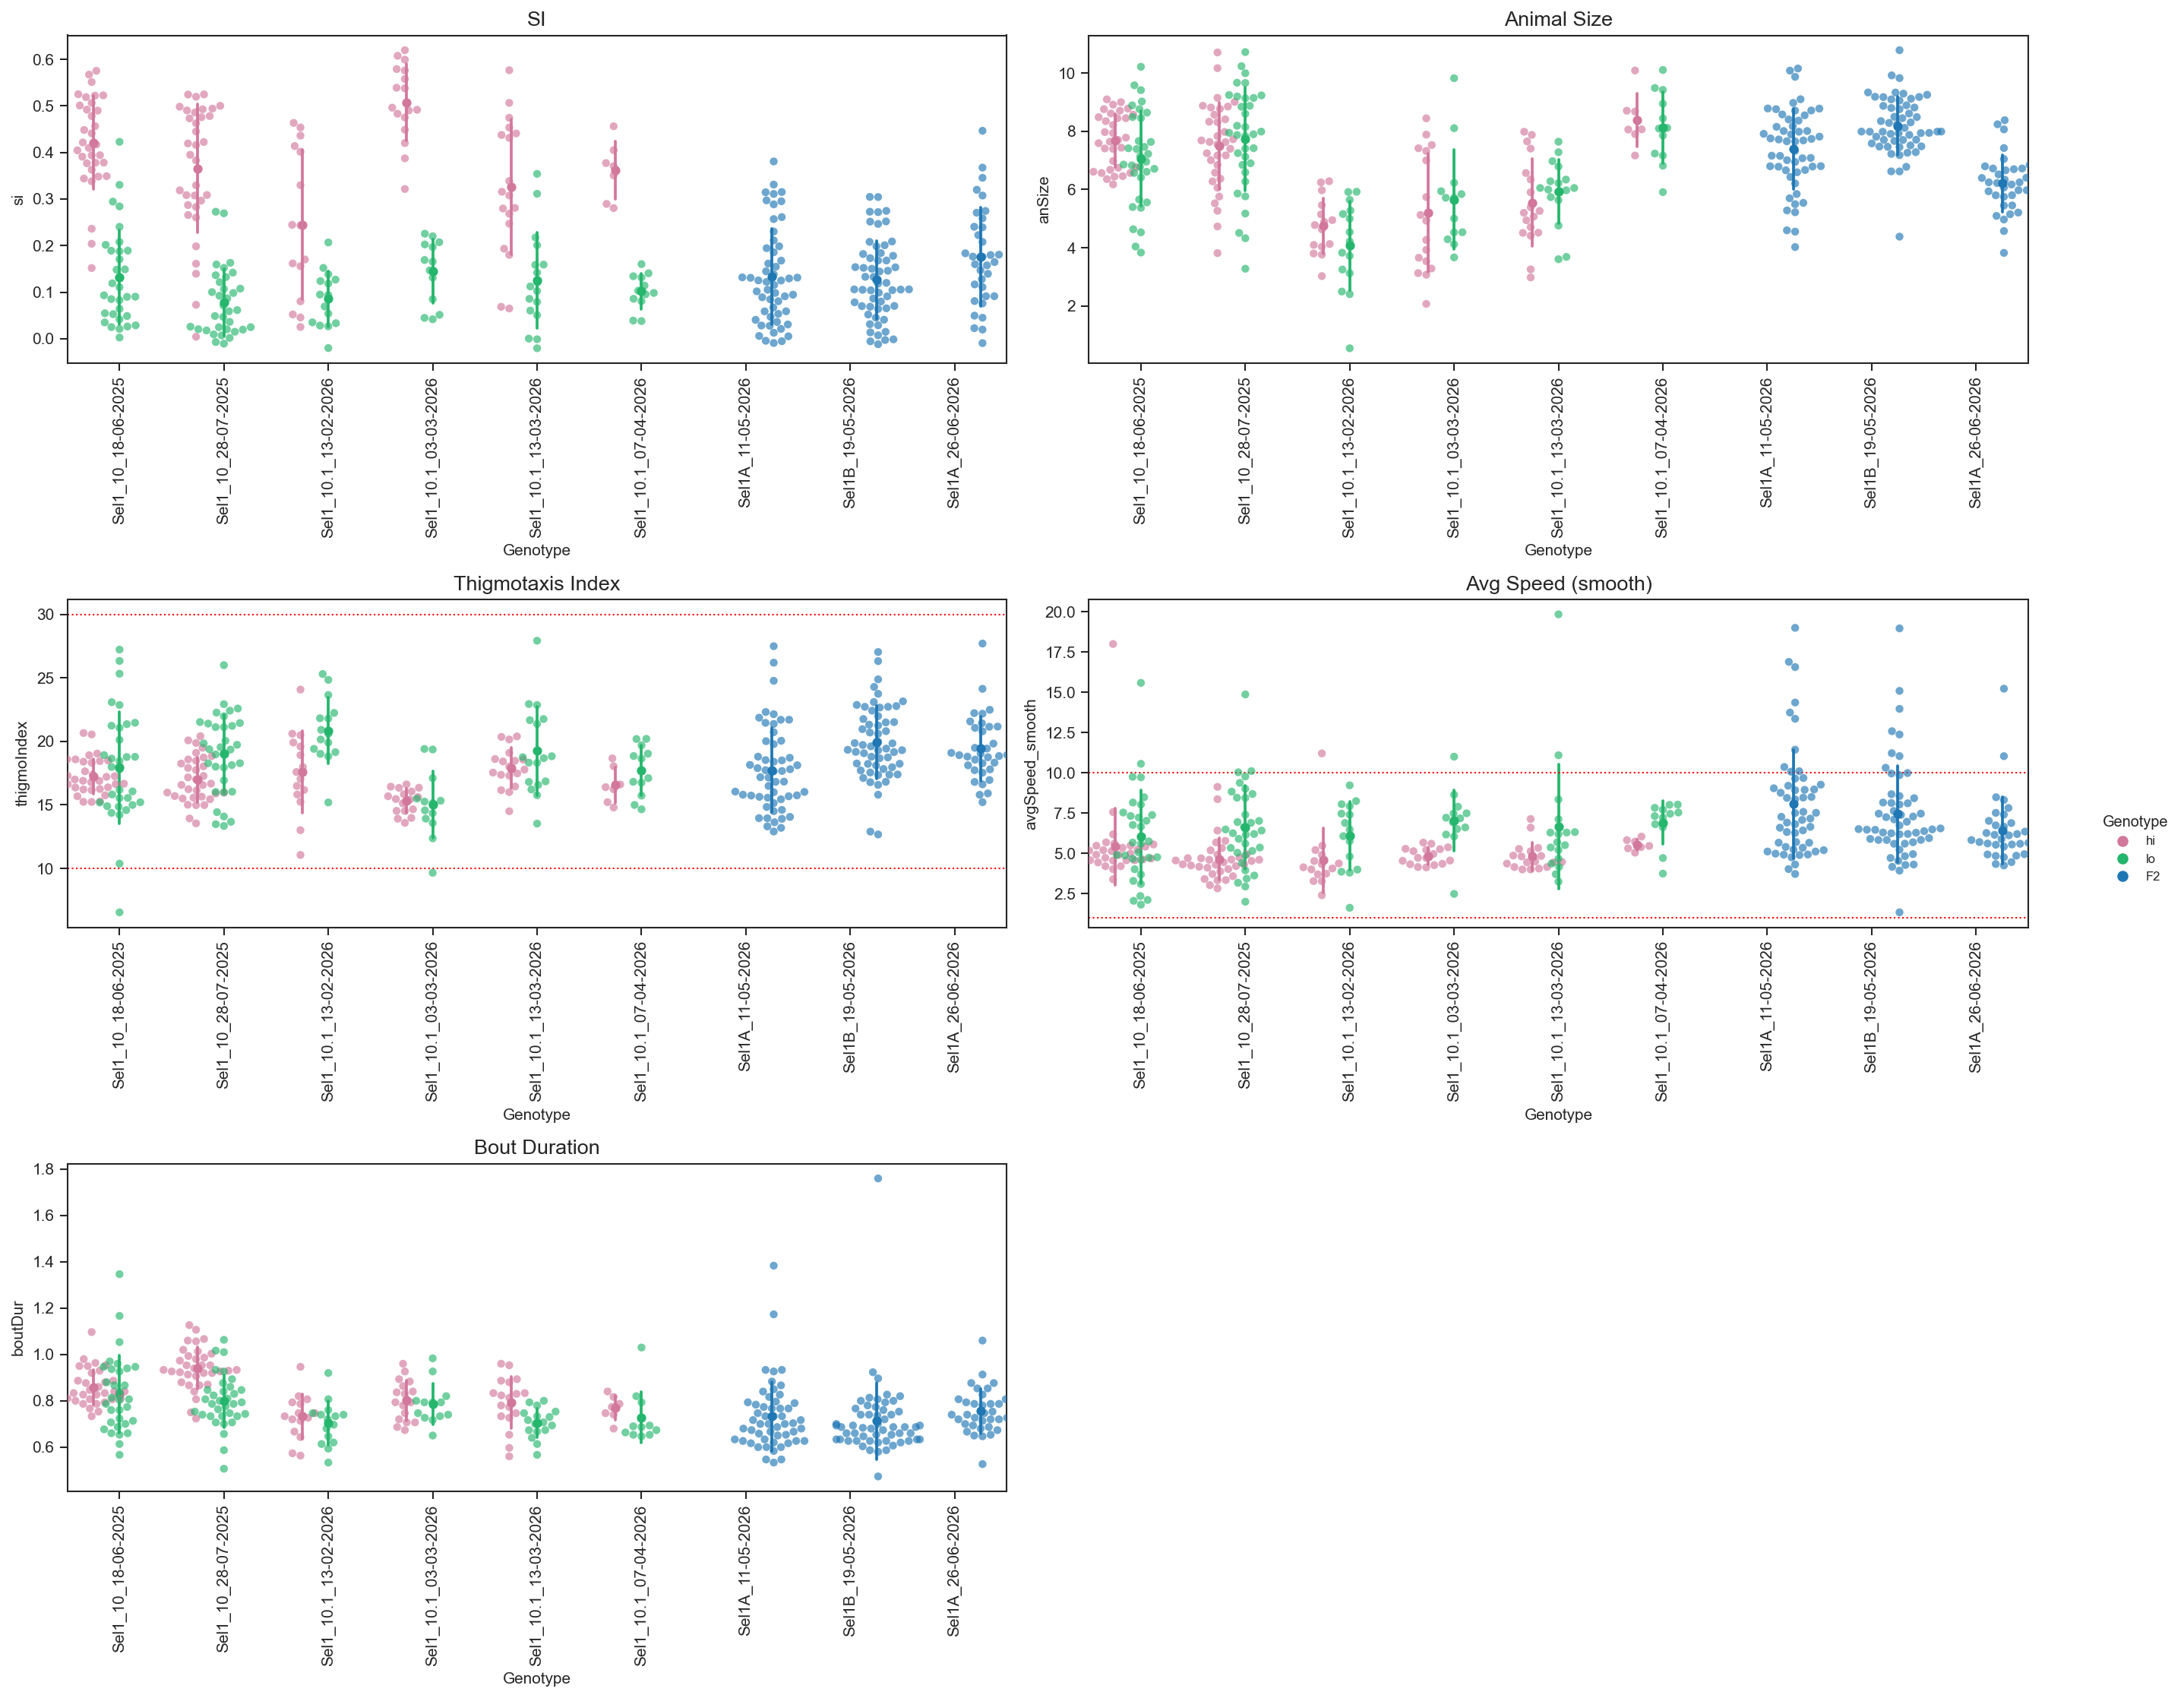

In [83]:

# Comparison of the different metrics across all Sel1 experiments

# -----------------------------
# Data filtering settings
# -----------------------------
comboEpiAn['date'] = pd.to_datetime(
    comboEpiAn['date'],
    format='%d-%m-%Y',
    dayfirst=True,
    errors='coerce'
)

exclude_date1 = pd.Timestamp('2025-07-28')
exclude_date2 = pd.Timestamp('2025-12-31')


ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    & (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    #& ((comboEpiAn['date'] >= exclude_date1))  #only include experiments from 2026, when the setup was stable and optimized
    & ((comboEpiAn['date'] <= exclude_date1) | (comboEpiAn['date'] >= exclude_date2)) #only include experiments from early 2025 or experiments from 2026, when the setup was stable and optimized
    & comboEpiAn['lineSet'].str.startswith('Sel1', na=False) # keep only data from Sel1 for more direct comparison
    & ~comboEpiAn['lineSet'].str.startswith('Sel1_GC', na=False) # exclude GC lines
)



data_for_plot = (
    comboEpiAn[ix]
    .groupby(['animalIndex', 'genotype', 'lineSet'])
    .mean(numeric_only=True)
    .reset_index()
)

# Drop missing values
data_for_plot = data_for_plot.dropna(
    subset=['anSize', 'thigmoIndex', 'boutDur', 'si', 'avgSpeed_smooth']
)

data_for_plot.lineSet.unique()


# -----------------------------
# Plot settings
# -----------------------------
custom_palette = {'hi': "#D2789C", 'lo': "#25B66D", 'F2': "#1F77B4"}
order = ['hi', 'lo', 'F2']

variables = ['si', 'anSize', 'thigmoIndex', 'avgSpeed_smooth', 'boutDur']
titles = ['SI', 'Animal Size', 'Thigmotaxis Index', 'Avg Speed (smooth)', 'Bout Duration']

# Optional thresholds
thresholds = {
    'avgSpeed_smooth': [1, 10],
    'thigmoIndex': [10, 30]
}

# -----------------------------
# NEW: Order lineSets by date
# -----------------------------
line_order = (
    comboEpiAn[ix]
    .groupby('lineSet')['date']
    .min()
    .sort_values()
    .index
)

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[i]

    # Mean Â± SD (pointplot)
    sns.pointplot(
        data=data_for_plot,
        x='lineSet',
        y=var,
        linestyle='none',
        errorbar='sd',
        hue='genotype',
        hue_order=order,
        palette=custom_palette,
        dodge=0.5,
        order=line_order,          # âœ… ordered by date
        legend=False,              # âœ… remove per-plot legends
        ax=ax
    )

    # Individual points (swarm)
    sns.swarmplot(
        data=data_for_plot,
        x='lineSet',
        y=var,
        size=5,
        alpha=0.65,
        hue='genotype',
        hue_order=order,
        palette=custom_palette,
        dodge=0.5,
        order=line_order,          # âœ… same ordering
        legend=False,              # âœ… remove per-plot legends
        ax=ax
    )

    # Capture legend handles ONCE
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    # Threshold lines if defined
    if var in thresholds:
        for y in thresholds[var]:
            ax.axhline(y, color='red', linestyle='dotted', linewidth=1)

    # Labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Genotype')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=90)

# Remove unused last subplot (6th slot)
fig.delaxes(axes[-1])

# -----------------------------
# NEW: Global legend outside plots (fixed)
# -----------------------------
from matplotlib.lines import Line2D

# Create custom legend handles manually
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=gen,
           markerfacecolor=custom_palette[gen], markersize=8)
    for gen in order
]

fig.legend(
    handles=legend_elements,
    title='Genotype',
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   # âœ… closer to plots
    frameon=False                 # optional: cleaner look
)

# -----------------------------
# NEW: Adjust layout to make space for legend
# -----------------------------
plt.tight_layout(rect=[0, 0, 0.9, 1])  # âœ… less empty space than before

plt.show()


### Comparison of the different metrics across all Sel3 experiments

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.wa

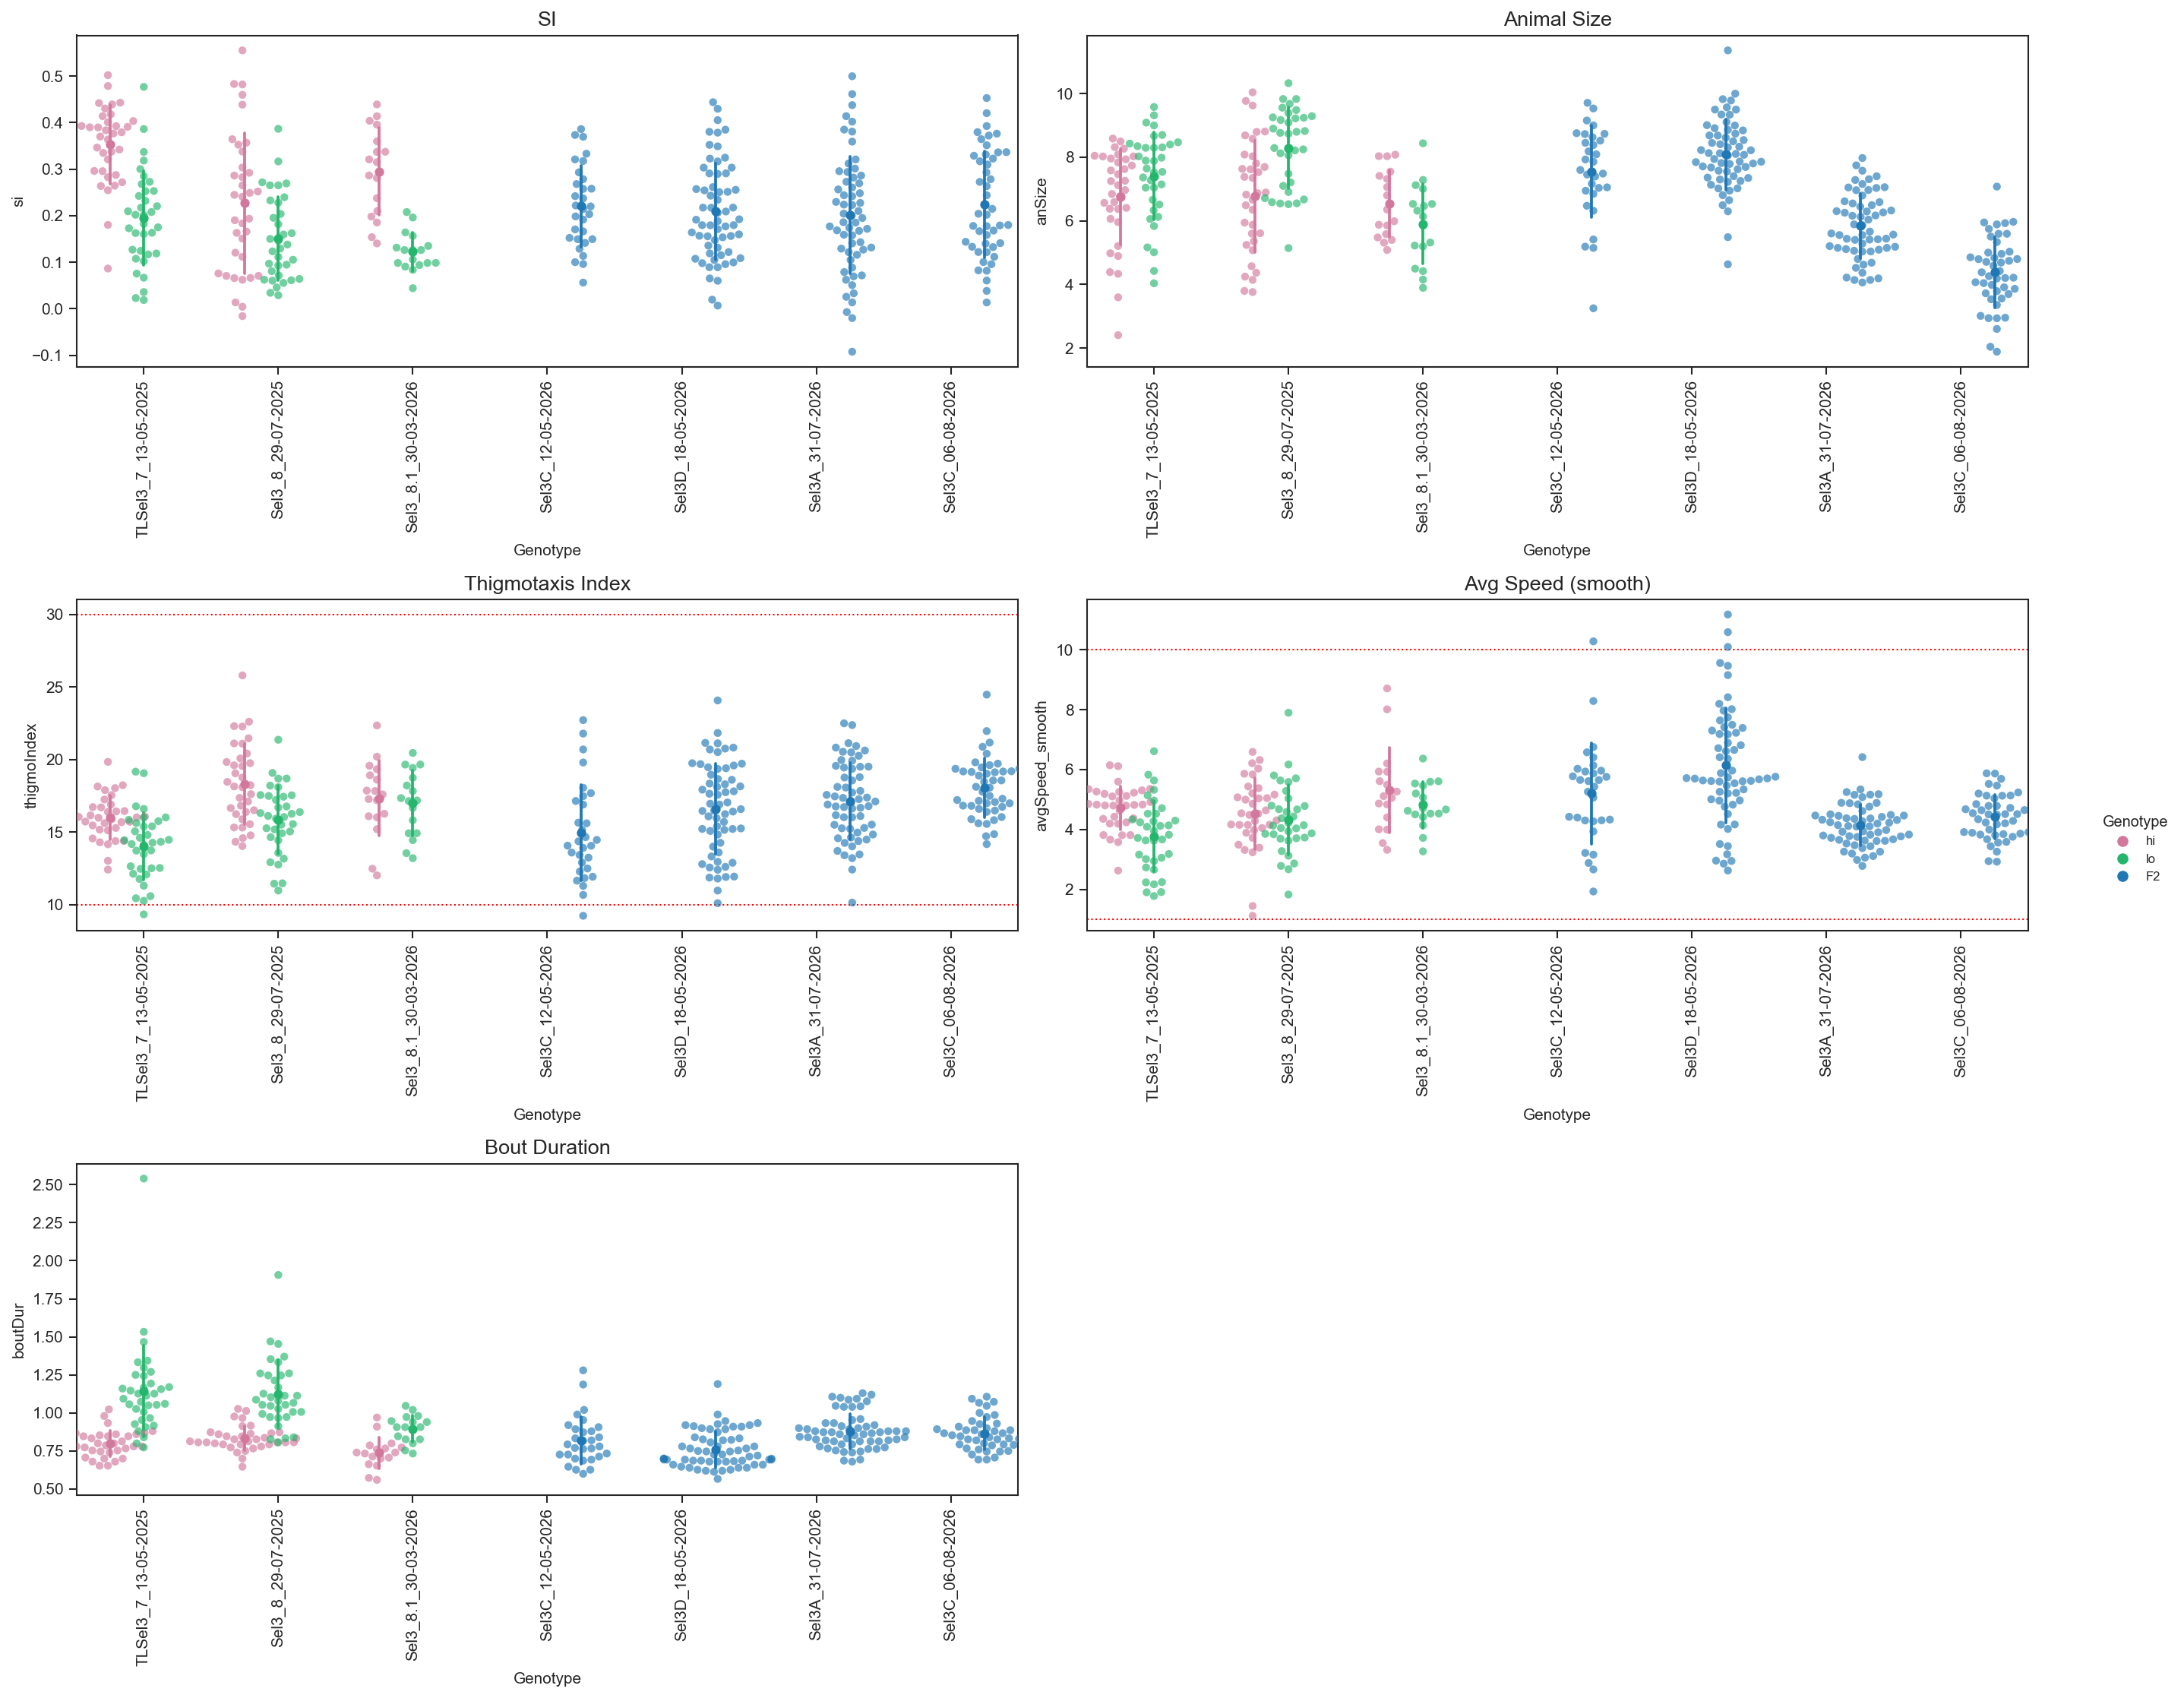

In [84]:

# Comparison of the different metrics across all Sel3 experiments

# -----------------------------
# Data filtering settings
# -----------------------------
comboEpiAn['date'] = pd.to_datetime(
    comboEpiAn['date'],
    format='%d-%m-%Y',
    dayfirst=True,
    errors='coerce'
)

exclude_date1 = pd.Timestamp('2025-07-29')
exclude_date2 = pd.Timestamp('2025-12-31')
exclude_date3 = pd.Timestamp('2025-01-28')


ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    & (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    #& ((comboEpiAn['date'] >= exclude_date1))  #only include experiments from 2026, when the setup was stable and optimized
    & ((comboEpiAn['date'] <= exclude_date1) | (comboEpiAn['date'] >= exclude_date2)) #only include experiments from early 2025 or experiments from 2026, when the setup was stable and optimized
    & (comboEpiAn['lineSet'].str.startswith('Sel3', na=False) |
       comboEpiAn['lineSet'].str.startswith('TLSel3', na=False)
       ) # keep only data from Sel3 for more direct comparison
    & (comboEpiAn['date'] != exclude_date3)  #exclude data from first experiment in Jan 2025
    & ~comboEpiAn['lineSet'].str.startswith('Sel3_GC', na=False) # exclude GC lines
)



data_for_plot = (
    comboEpiAn[ix]
    .groupby(['animalIndex', 'genotype', 'lineSet'])
    .mean(numeric_only=True)
    .reset_index()
)

# Drop missing values
data_for_plot = data_for_plot.dropna(
    subset=['anSize', 'thigmoIndex', 'boutDur', 'si', 'avgSpeed_smooth']
)

data_for_plot.lineSet.unique()


# -----------------------------
# Plot settings
# -----------------------------
custom_palette = {'hi': "#D2789C", 'lo': "#25B66D", 'F2': "#1F77B4"}
order = ['hi', 'lo', 'F2']

variables = ['si', 'anSize', 'thigmoIndex', 'avgSpeed_smooth', 'boutDur']
titles = ['SI', 'Animal Size', 'Thigmotaxis Index', 'Avg Speed (smooth)', 'Bout Duration']

# Optional thresholds
thresholds = {
    'avgSpeed_smooth': [1, 10],
    'thigmoIndex': [10, 30]
}

# -----------------------------
# NEW: Order lineSets by date
# -----------------------------
line_order = (
    comboEpiAn[ix]
    .groupby('lineSet')['date']
    .min()
    .sort_values()
    .index
)

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[i]

    # Mean Â± SD (pointplot)
    sns.pointplot(
        data=data_for_plot,
        x='lineSet',
        y=var,
        linestyle='none',
        errorbar='sd',
        hue='genotype',
        hue_order=order,
        palette=custom_palette,
        dodge=0.5,
        order=line_order,          # âœ… ordered by date
        legend=False,              # âœ… remove per-plot legends
        ax=ax
    )

    # Individual points (swarm)
    sns.swarmplot(
        data=data_for_plot,
        x='lineSet',
        y=var,
        size=5,
        alpha=0.65,
        hue='genotype',
        hue_order=order,
        palette=custom_palette,
        dodge=0.5,
        order=line_order,          # âœ… same ordering
        legend=False,              # âœ… remove per-plot legends
        ax=ax
    )

    # Capture legend handles ONCE
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    # Threshold lines if defined
    if var in thresholds:
        for y in thresholds[var]:
            ax.axhline(y, color='red', linestyle='dotted', linewidth=1)

    # Labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Genotype')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=90)

# Remove unused last subplot (6th slot)
fig.delaxes(axes[-1])

# -----------------------------
# NEW: Global legend outside plots (fixed)
# -----------------------------
from matplotlib.lines import Line2D

# Create custom legend handles manually
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=gen,
           markerfacecolor=custom_palette[gen], markersize=8)
    for gen in order
]

fig.legend(
    handles=legend_elements,
    title='Genotype',
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   # âœ… closer to plots
    frameon=False                 # optional: cleaner look
)

# -----------------------------
# NEW: Adjust layout to make space for legend
# -----------------------------
plt.tight_layout(rect=[0, 0, 0.9, 1])  # âœ… less empty space than before

plt.show()

## Escapee fish analysis

### Sel1 escapee

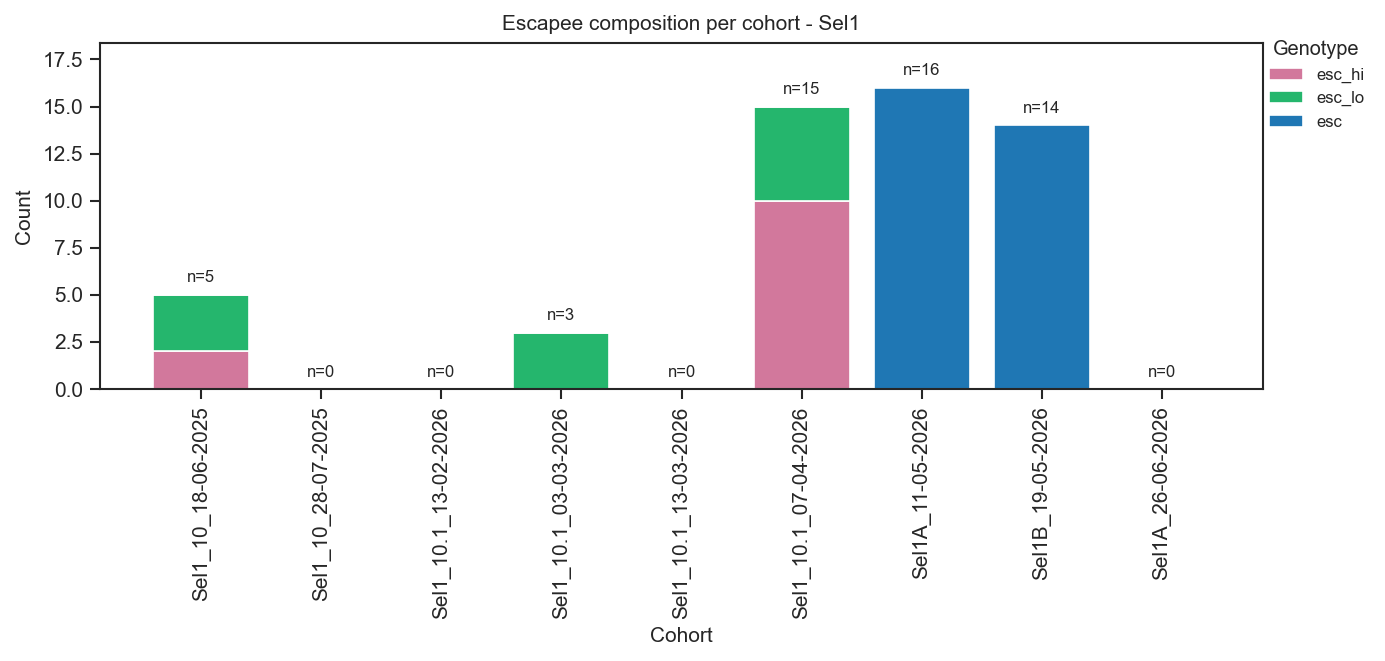

In [85]:
# Count esc_hi/esc_lo Sel1 samples per cohort and plot chronologically

# -----------------------------
# Data filtering settings
# -----------------------------
comboEpiAn['date'] = pd.to_datetime(
    comboEpiAn['date'],
    format='%d-%m-%Y',
    dayfirst=True,
    errors='coerce'
)

exclude_date1 = pd.Timestamp('2025-07-28')
exclude_date2 = pd.Timestamp('2025-12-31')

ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    #& (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    #& ((comboEpiAn['date'] >= exclude_date1))  #only include experiments from 2026, when the setup was stable and optimized
    & ((comboEpiAn['date'] <= exclude_date1) | (comboEpiAn['date'] >= exclude_date2)) #only include experiments from early 2025 or experiments from 2026, when the setup was stable and optimized
    & comboEpiAn['lineSet'].str.startswith('Sel1', na=False) # keep only data from Sel1 for more direct comparison
    & ~comboEpiAn['lineSet'].str.startswith('Sel1_GC', na=False) # exclude GC lines
)

# Determine plotting order
line_order = (
    comboEpiAn[['lineSet', 'date']][ix]
    .drop_duplicates()
    .sort_values('date')['lineSet']
    .tolist()
)

# Aggregate per animal, genotype and lineSet
plotdata = (
    comboEpiAn[ix]
    .groupby(['animalIndex', 'genotype', 'lineSet'])
    .mean(numeric_only=True)
    .reset_index()
)

# Drop missing values
plotdata = plotdata.dropna(
    subset=['anSize', 'thigmoIndex', 'boutDur', 'si', 'avgSpeed_smooth']
)

# -----------------------------
# Count escape genotypes
# -----------------------------
esc_mask = plotdata['genotype'].isin(['esc_hi', 'esc_lo', 'esc'])

esc_counts = (
    plotdata[esc_mask]
    .groupby(['lineSet', 'genotype'])
    .size()
    .reset_index(name='count')
)

# Ensure all combinations exist
full_index = pd.MultiIndex.from_product(
    [line_order, ['esc_hi', 'esc_lo', 'esc']],
    names=['lineSet', 'genotype']
)

esc_counts = (
    esc_counts.set_index(['lineSet', 'genotype'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Pivot for stacking
esc_pivot = (
    esc_counts
    .pivot(index='lineSet', columns='genotype', values='count')
    .reindex(line_order)
    .fillna(0)
)

# -----------------------------
# Plot stacked barplot (counts)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 3))

bottom = np.zeros(len(esc_pivot))
colors = {
    'esc_hi': '#D2789C',
    'esc_lo': '#25B66D',
    'esc': '#1F77B4'
}

for genotype in ['esc_hi', 'esc_lo', 'esc']:
    values = esc_pivot[genotype]
    ax.bar(
        esc_pivot.index,
        values,
        bottom=bottom,
        label=genotype,
        color=colors[genotype]
    )
    bottom += values

# Axis formatting
ax.set_ylim(0, bottom.max() * 1.15)
ax.set_xlabel('Cohort')
ax.set_ylabel('Count')
ax.set_title('Escapee composition per cohort - Sel1')
plt.xticks(rotation=90)
plt.legend(title='Genotype', bbox_to_anchor=(1.1, 1.05), frameon=False)

# -----------------------------
# Add total sample size on top
# -----------------------------
totals = esc_pivot.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 0.5,
        f'n={int(total)}',
        ha='center',
        va='bottom',
        fontsize=8
    )


### Sel3 escapee

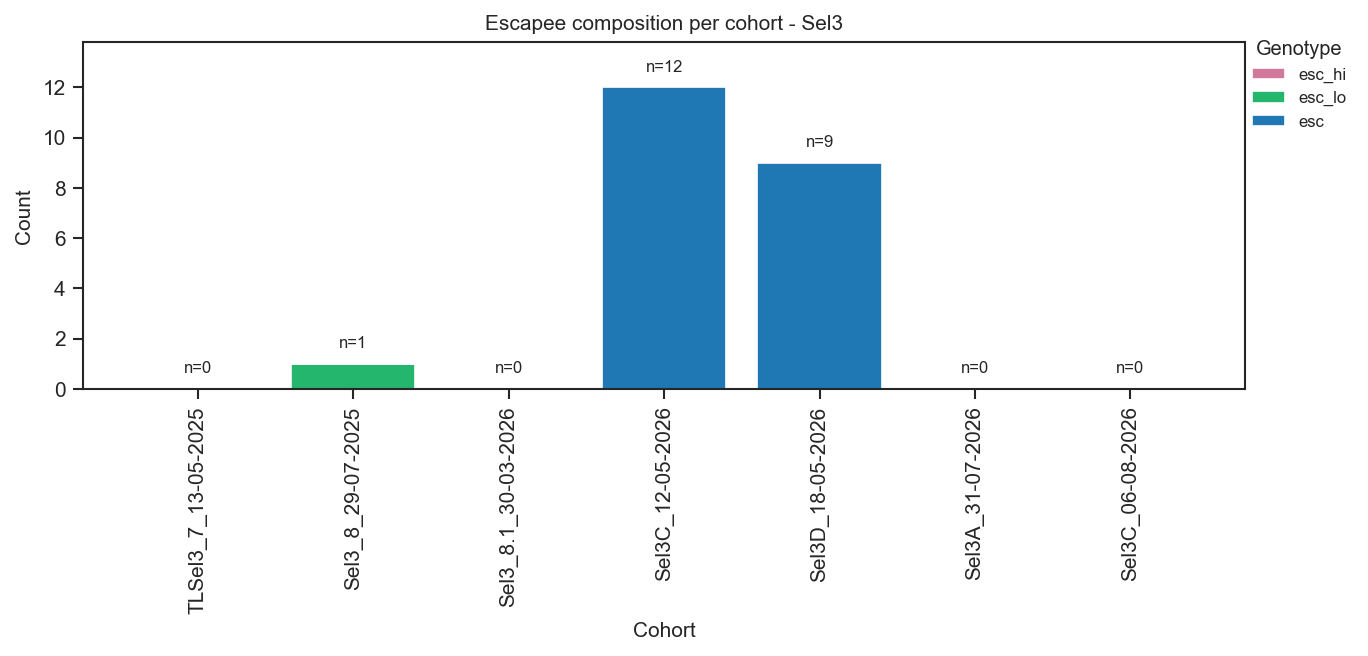

In [86]:
# Count esc_hi/esc_lo Sel3 samples per cohort and plot chronologically

# -----------------------------
# Data filtering settings
# -----------------------------
comboEpiAn['date'] = pd.to_datetime(
    comboEpiAn['date'],
    format='%d-%m-%Y',
    dayfirst=True,
    errors='coerce'
)

exclude_date1 = pd.Timestamp('2025-07-29')
exclude_date2 = pd.Timestamp('2025-12-31')
exclude_date3 = pd.Timestamp('2025-01-28')

ix = (
    (comboEpiAn['episode'] == '02k20f') #only use shoaling attraction to bout-like stimulus
    #& (comboEpiAn['genotype'].isin(['F2', 'hi', 'lo']))  # keep all genotypes but exclude na's or escapees from analysis
    & (comboEpiAn['boutDur'] < 4)  #filter extreme bout duration values
    #& ((comboEpiAn['date'] >= exclude_date1))  #only include experiments from 2026, when the setup was stable and optimized
    & ((comboEpiAn['date'] <= exclude_date1) | (comboEpiAn['date'] >= exclude_date2)) #only include experiments from early 2025 or experiments from 2026, when the setup was stable and optimized
    & (comboEpiAn['date'] != exclude_date3)  #exclude data from first experiment in Jan 2025
    & (comboEpiAn['lineSet'].str.startswith('Sel3', na=False) | comboEpiAn['lineSet'].str.startswith('TLSel3', na=False)) # keep only data from Sel3 for more direct comparison
)

# Determine plotting order
line_order = (
    comboEpiAn[['lineSet', 'date']][ix]
    .drop_duplicates()
    .sort_values('date')['lineSet']
    .tolist()
)

# Aggregate per animal, genotype and lineSet
plotdata = (
    comboEpiAn[ix]
    .groupby(['animalIndex', 'genotype', 'lineSet'])
    .mean(numeric_only=True)
    .reset_index()
)

# Drop missing values
plotdata = plotdata.dropna(
    subset=['anSize', 'thigmoIndex', 'boutDur', 'si', 'avgSpeed_smooth']
)

# -----------------------------
# Count escape genotypes
# -----------------------------
esc_mask = plotdata['genotype'].isin(['esc_hi', 'esc_lo', 'esc'])

esc_counts = (
    plotdata[esc_mask]
    .groupby(['lineSet', 'genotype'])
    .size()
    .reset_index(name='count')
)

# Ensure all combinations exist
full_index = pd.MultiIndex.from_product(
    [line_order, ['esc_hi', 'esc_lo', 'esc']],
    names=['lineSet', 'genotype']
)

esc_counts = (
    esc_counts.set_index(['lineSet', 'genotype'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Pivot for stacking
esc_pivot = (
    esc_counts
    .pivot(index='lineSet', columns='genotype', values='count')
    .reindex(line_order)
    .fillna(0)
)

# -----------------------------
# Plot stacked barplot (counts)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 3))

bottom = np.zeros(len(esc_pivot))
colors = {
    'esc_hi': '#D2789C',
    'esc_lo': '#25B66D',
    'esc': '#1F77B4'
}

for genotype in ['esc_hi', 'esc_lo', 'esc']:
    values = esc_pivot[genotype]
    ax.bar(
        esc_pivot.index,
        values,
        bottom=bottom,
        label=genotype,
        color=colors[genotype]
    )
    bottom += values

# Axis formatting
ax.set_ylim(0, bottom.max() * 1.15)
ax.set_xlabel('Cohort')
ax.set_ylabel('Count')
ax.set_title('Escapee composition per cohort - Sel3')
plt.xticks(rotation=90)
plt.legend(title='Genotype', bbox_to_anchor=(1.1, 1.05), frameon=False)

# -----------------------------
# Add total sample size on top
# -----------------------------
totals = esc_pivot.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 0.5,
        f'n={int(total)}',
        ha='center',
        va='bottom',
        fontsize=8
    )


# Re-analyze shoaling data but filter extreme values of boutDur, avgspeed and thigmotaxis

Filtered-in points: 300
Filtered-out points: 41
         lineSet  False  True
Sel1A_11-05-2026     17    36
Sel1A_26-06-2026      3    32
Sel1B_19-05-2026     12    44
Sel3A_31-07-2026      0    59
Sel3C_06-08-2026      0    46
Sel3C_12-05-2026      3    28
Sel3D_18-05-2026      6    55


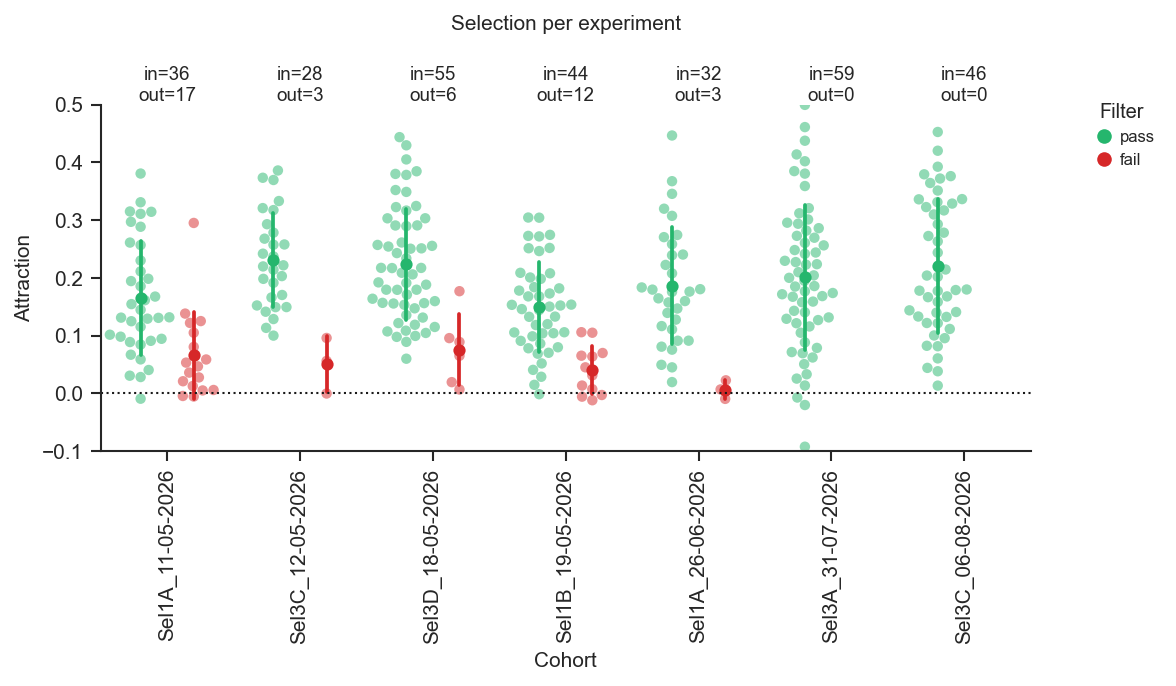

In [87]:
fig, axes = plt.subplots(figsize=(8, 3))
#ix=(dfEpiAn.episode=='02k20f')
#ix=(dfEpiAn.episode=='02k20f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo')) & (dfEpiAn.date!='01-09-2025')  # filter out inverted experiment
#ix=(dfEpiAn.episode=='01k01f')&((dfEpiAn.genotype=='hi') | (dfEpiAn.genotype=='lo')) & (dfEpiAn.date!='01-09-2025') # plot data for linear stimuli

ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='F2')

selDat_all = dfEpiAn[ix].copy()

#Filter settings. Values empirically derived from looking at the distributions, can be adjusted as needed to filter out extreme outliers that may be due to tracking errors or sick fish.
max_speed = 10
min_speed = 1 
max_boutDur = 5 
min_boutDur = 0.1 
max_thigmoIndex = 30 
min_thigmoIndex = 10

filter_mask = (selDat_all.avgSpeed < max_speed) & (selDat_all.avgSpeed > min_speed) & (selDat_all.boutDur < max_boutDur) & (selDat_all.boutDur > min_boutDur) & (selDat_all.thigmoIndex < max_thigmoIndex) & (selDat_all.thigmoIndex > min_thigmoIndex)
selDat_all['filter_pass'] = filter_mask

#Settings

show_lines = "All" 
#show_lines = [ "TLSel3_7","Sel3_7", "Sel3_8"]  # set the lines you want to keep
#show_lines = [ "TLSel1_9","Sel1_10", "Sel1_11"]  # set the lines you want to keep
#show_lines = [ "Sel1_GC"]  # set the lines you want to keep
xlegend_orientation = 'vertical' #choose verticar or horizontal


if show_lines != "All":
    selDat_all = selDat_all[selDat_all['line'].isin(show_lines)]

selDat = selDat_all[selDat_all['filter_pass']].copy()

print(f'Filtered-in points: {len(selDat)}')
print(f'Filtered-out points: {len(selDat_all) - len(selDat)}')

allCat=selDat_all.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

summary_counts = selDat_all.groupby(['lineSet', 'filter_pass']).size().unstack(fill_value=0).reset_index()
print(summary_counts.to_string(index=False))

filter_palette = {True: '#25B66D', False: '#D62728'}
filter_order = [True, False]

sns.swarmplot(data=selDat_all,
              x='lineSet',
              y='si',
              hue='filter_pass',
              palette=filter_palette,
              hue_order=filter_order,
              zorder=-1,
              dodge=.5,
              size=5,
              alpha=.5)

sns.pointplot(data=selDat_all,
              x='lineSet',
              y='si',
              hue='filter_pass',
              palette=filter_palette,
              hue_order=filter_order,
              linestyle='none',
              errorbar='sd',
              dodge=0.4
              )


sns.despine()
axes.set_ylim([-0.1,0.5])

axes.set_ylabel('Attraction')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');


def split_label(label):
    label_str = str(label)

    # Split on the last underscore ( format is "LineID_Date")
    parts = label_str.rsplit('_', 1)
    return parts[0] + '\n' + parts[1]


if xlegend_orientation == 'horizontal':
    # Keep labels flat when the layout is horizontal.
    axes.set_xticklabels([split_label(t.get_text()) for t in axes.get_xticklabels()], rotation=0)
else:
    # Rotate labels to keep long cohort names readable.
    plt.xticks(rotation=90);

# Annotate each cohort with the number of points that passed or failed the filters.
xticklabels = [t.get_text() for t in axes.get_xticklabels()]
xticks = axes.get_xticks()
for xpos, label in zip(xticks, xticklabels):
    if label in summary_counts['lineSet'].values:
        row = summary_counts.loc[summary_counts['lineSet'] == label].iloc[0]
        pass_count = int(row.get(True, 0))
        fail_count = int(row.get(False, 0))
        axes.text(
            xpos,
            1.00,
            f'in={pass_count}\nout={fail_count}',
            transform=axes.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=9,
        )

# Keep the title above the count annotations, with extra padding so they do not crowd each other.
plt.title('Selection per experiment', pad=36);

if axes.get_legend() is not None:
    axes.get_legend().remove()

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='pass', markerfacecolor=filter_palette[True], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='fail', markerfacecolor=filter_palette[False], markersize=8),
    ]
l = plt.legend(legend_handles, ['pass', 'fail'], title='Filter', ncol=1, handletextpad=0,
               bbox_to_anchor=(1.15, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')


# Save the plot using the path variable

if show_lines == "All":
    plt.savefig(os.path.join(outputDir, "shoalindex_hivslo.pdf"), bbox_inches="tight")

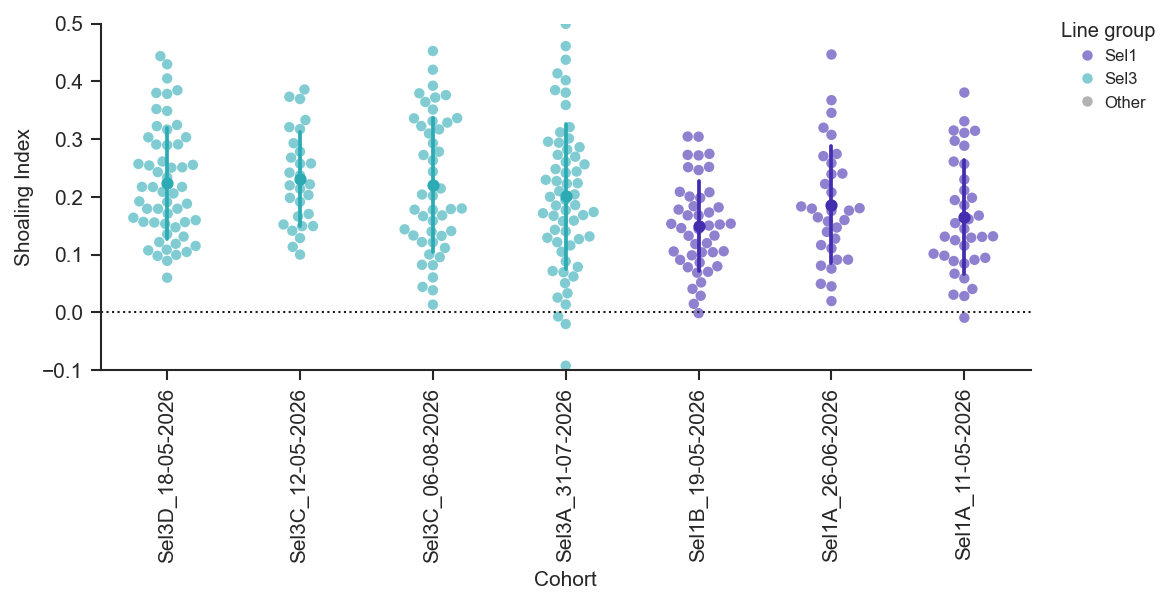

In [88]:
fig, axes = plt.subplots(figsize=(8, 3))
# Pass-only plot colored by Sel1 vs Sel3 experiments.
ix = (dfEpiAn.episode == '02k20f') & (dfEpiAn.genotype == 'F2')
selDat_all = dfEpiAn[ix].copy()

# Filter settings (same as previous cell).
max_speed = 10
min_speed = 1
max_boutDur = 5
min_boutDur = 0.1
max_thigmoIndex = 30
min_thigmoIndex = 10

filter_mask = (
    (selDat_all.avgSpeed < max_speed)
    & (selDat_all.avgSpeed > min_speed)
    & (selDat_all.boutDur < max_boutDur)
    & (selDat_all.boutDur > min_boutDur)
    & (selDat_all.thigmoIndex < max_thigmoIndex)
    & (selDat_all.thigmoIndex > min_thigmoIndex)
 )
selDat = selDat_all[filter_mask].copy()

# Group experiments by Sel1 vs Sel3 based on line labels.
line_labels = selDat['line'].astype(str)
selDat['sel_group'] = np.select(
    [
        line_labels.str.contains('Sel1', case=False, na=False),
        line_labels.str.contains('Sel3', case=False, na=False),
    ],
    ['Sel1', 'Sel3'],
    default='Other',
)

group_palette = {'Sel1': "#452daf", 'Sel3': "#2cabb4", 'Other': '#7f7f7f'}
group_order = ['Sel1', 'Sel3', 'Other']

allCat = selDat.lineSet.unique()
allCat.sort()
allCat = allCat[::-1]

sns.swarmplot(
    data=selDat,
    x='lineSet',
    y='si',
    hue='sel_group',
    palette=group_palette,
    hue_order=group_order,
    order=allCat,
    zorder=-1,
   # dodge=.5,
    size=5,
    alpha=.6,
 )

sns.pointplot(
    data=selDat,
    x='lineSet',
    y='si',
    hue='sel_group',
    palette=group_palette,
    hue_order=group_order,
    order=allCat,
    linestyle='none',
    errorbar='sd',
    #dodge=0.4,
 )

sns.despine()
axes.set_ylim([-0.1, 0.5])
axes.set_ylabel('Shoaling Index')
axes.set_xlabel('Cohort')
axes.axhline(0, ls=':', color='k')
plt.xticks(rotation=90);

# Clean legend to avoid duplicates from swarm + point overlays.
handles, labels = axes.get_legend_handles_labels()
unique_handles = []
unique_labels = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)
plt.legend(unique_handles, unique_labels, title='Line group', ncol=1, handletextpad=0, bbox_to_anchor=(1.15, 1.05), frameon=False)

# Save the plot using the path variable.
plt.savefig(os.path.join(outputDir, 'shoalindex_pass_sel1_sel3.pdf'), bbox_inches='tight')